### Topological data analysis

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
<div style="width: 50%; margin-right: 20px;">
<h2>Introduction</h2>
<p>This analysis applies custom topological data analysis to 3D EEG delay-embedding trajectories. Instead of relying on GUDHI or another persistent homology library, the pipeline constructs a sparse Vietoris-Rips complex manually and performs persistent homology using binary column reduction over \(\mathbb{Z}_2\). The goal is to quantify loop-like, component-like, and higher-order geometric structure in each EEG channel after projection into two dimensions.</p>
<h2>Input Data</h2>
<p>Each EEG channel is loaded as a 3D embedded trajectory \(X \in \mathbb{R}^{N \times 3}\), where \(N\) is the number of embedded time points. Each row represents a point in reconstructed state space, and each channel is analyzed independently.</p>
<h2>Standardization</h2>
<p>The 3D trajectory is standardized column-wise so each coordinate contributes comparably to projection and topology.</p>
<p><strong>Formula:</strong></p>
\[
Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j + \epsilon}
\]
<p>where \(X_{ij}\) is the original embedded value, \(\mu_j\) is the mean of coordinate \(j\), \(\sigma_j\) is the standard deviation of coordinate \(j\), and \(\epsilon\) prevents division by zero.</p>
<h2>Projection</h2>
<p>The standardized 3D trajectory is projected to a 2D point cloud. If a previously saved UMAP embedding exists, it is reused. If no saved embedding exists, the code computes a new UMAP projection. If UMAP is unavailable, the code can fall back to PCA.</p>
<p><strong>Projection Form:</strong></p>
\[
Y = f(X), \quad Y \in \mathbb{R}^{N \times 2}
\]
<p>where \(f\) is either UMAP or PCA, and \(Y\) is the projected 2D point cloud used for topology.</p>
<h2>Topology Subsampling</h2>
<p>Persistent homology is expensive for large point clouds, so the projected trajectory is randomly subsampled before constructing the complex. This keeps the analysis computationally feasible while preserving a representative geometric sample.</p>
<p><strong>Subsample:</strong></p>
\[
Y_{\text{sub}} = \{y_i : i \in S\}, \quad |S| \leq N_{\max}
\]
<p>where \(S\) is a random subset of point indices and \(N_{\max}\) is the maximum number of topology points.</p>
<h2>Sparse Vietoris-Rips Graph</h2>
<p>The code constructs a sparse Rips graph using local nearest neighbors rather than all pairwise distances. This greatly reduces computational cost.</p>
<p><strong>Edge Rule:</strong></p>
\[
(i,j) \in E \quad \text{if} \quad d(y_i,y_j) \leq \epsilon \quad \text{and} \quad y_j \in kNN(y_i)
\]
<p>where \(d(y_i,y_j)\) is Euclidean distance, \(\epsilon\) is the maximum edge length, and \(kNN(y_i)\) is the set of nearest neighbors of point \(y_i\).</p>
<h2>Triangle Construction</h2>
<p>A triangle is added when all three pairwise edges between three points exist. The triangle enters the filtration at the largest edge length among its boundary edges.</p>
<p><strong>Triangle Rule:</strong></p>
\[
[i,j,k] \in K \quad \text{if} \quad [i,j], [i,k], [j,k] \in E
\]
<p><strong>Triangle Filtration:</strong></p>
\[
f([i,j,k]) = \max(d_{ij}, d_{ik}, d_{jk})
\]
<p>This lets loops die when they become filled by triangles.</p>
<h2>Boundary Operators</h2>
<p>The custom persistent homology implementation works over \(\mathbb{Z}_2\), meaning all addition is modulo 2. This allows boundaries to be represented as sets, where repeated terms cancel.</p>
<p><strong>Boundary of an Edge:</strong></p>
\[
\partial[i,j] = [i] + [j]
\]
<p><strong>Boundary of a Triangle:</strong></p>
\[
\partial[i,j,k] = [i,j] + [i,k] + [j,k]
\]
<p>Over \(\mathbb{Z}_2\), adding the same simplex twice cancels it.</p>
<h2>Column Reduction</h2>
<p>Persistent homology is computed by reducing the boundary matrix column by column. A simplex with an empty reduced boundary creates a topological feature. A simplex with a nonempty reduced boundary destroys the feature born at the lowest boundary index.</p>
<p><strong>Reduction Rule:</strong></p>
\[
R_j \leftarrow R_j + R_k \pmod{2}
\]
<p>where \(R_j\) is the current boundary column and \(R_k\) is a previous column with the same lowest nonzero row.</p>
</div>
<div style="width: 50%; margin-left: 20px;">
<h2>Persistence Intervals</h2>
<p>Each topological feature is represented as an interval \([b_i,d_i]\), where \(b_i\) is the birth scale and \(d_i\) is the death scale. Long intervals represent more persistent and potentially more meaningful structures.</p>
<p><strong>Lifetime:</strong></p>
\[
\ell_i = d_i - b_i
\]
<p>where \(\ell_i\) is the persistence lifetime of feature \(i\).</p>
<h2>Betti Numbers</h2>
<p>Betti numbers count surviving topological structures. \(\beta_0\) counts connected components, \(\beta_1\) counts loop-like structures, and \(\beta_2\) is treated as a conservative diagnostic because tetrahedra are not included in this implementation.</p>
<p><strong>Formula:</strong></p>
\[
\beta_k = \text{rank}(H_k)
\]
<p>where \(H_k\) is the \(k\)-th homology group.</p>
<h2>H0, H1, and H2 Interpretation</h2>
<p>\(H_0\) describes how separate connected components merge as the distance scale increases. \(H_1\) captures loop-like or recurrent structures in the projected trajectory. \(H_2\) is included as a diagnostic of higher-order void-like structure, but because the complex includes vertices, edges, and triangles only, \(H_2\) should be interpreted cautiously.</p>
<h2>Persistent Entropy</h2>
<p>Persistent entropy measures how evenly persistence lifetime is distributed across features. A low entropy means a few features dominate, while a high entropy means persistence is spread across many features.</p>
<p><strong>Formula:</strong></p>
\[
S = -\frac{1}{\log(n)} \sum_{i=1}^{n} p_i \log(p_i), \quad p_i = \frac{\ell_i}{\sum_j \ell_j}
\]
<p>where \(p_i\) is the normalized lifetime of feature \(i\).</p>
<h2>Topological Complexity Score</h2>
<p>The code summarizes each channel using a weighted complexity score based on loop persistence, higher-dimensional diagnostic persistence, and finite feature counts.</p>
<p><strong>Formula:</strong></p>
\[
C_{\text{topo}} = P_{H1} + 0.50P_{H2} + 0.10N_{H1} + 0.05N_{H2}
\]
<p>where \(P_{H1}\) and \(P_{H2}\) are total persistence values, and \(N_{H1}\) and \(N_{H2}\) are finite feature counts.</p>
<h2>Projection Geometry Metrics</h2>
<p>The code computes additional geometric descriptors of the projected point cloud, including bounding-box area, density, nearest-neighbor distance, and covariance anisotropy. These help distinguish true topology from projection artifacts or sampling density effects.</p>
<p><strong>Anisotropy:</strong></p>
\[
A = \frac{\lambda_{\max}}{\lambda_{\min}}
\]
<p>where \(\lambda_{\max}\) and \(\lambda_{\min}\) are eigenvalues of the 2D projection covariance matrix.</p>
<h2>Classifier Diagnostic</h2>
<p>A random forest classifier is trained on synthetic alternating temporal segment labels. This is not a clinical or biological label model. It is a diagnostic test of whether the projected trajectory separates temporal structure strongly enough for a nonlinear classifier to exploit.</p>
<h2>Quality Control</h2>
<p>The code records the number of vertices, edges, triangles, and simplices in the sparse Rips complex. It also records whether the triangle cap was reached. These diagnostics identify channels where topology may be limited by computational constraints.</p>
<h2>Expert Plots</h2>
<p>The notebook generates black-background cyan plots for topological complexity rankings, H1 persistence rankings, Betti heatmaps, runtime quality control, complexity versus sparse Rips size, projection geometry versus topology, classifier accuracy versus topology, metric correlations, H1 lifetime overlays, persistence diagram galleries, projection galleries, persistent feature counts, and triangle-cap quality control.</p>
<h2>Results and Conclusion</h2>
<p>This custom-math topology pipeline provides a self-contained way to analyze nonlinear EEG channel geometry without GUDHI. Channels with high \(H_1\) persistence and high topological complexity may contain stronger recurrent or loop-like state-space structure. Runtime and triangle-cap diagnostics help determine whether the sparse complex was sufficiently expressive. Together, the persistence intervals, Betti numbers, geometry metrics, classifier diagnostic, and expert plots provide a compact framework for comparing nonlinear EEG dynamics across channels.</p>
</div>
</div>

Running custom-math topology from 3D projection pipeline
FAST_OPTION: fast
GUDHI used: False
UMAP available: False
PCA fallback available: True
cKDTree available: True
Notebook plot display: True
Save plots to disk: True
Optional per-channel plots enabled: False
Persistence cache reuse: True
Channels to process: 32

[1/32] Processing Fp1 | 3D shape=(106936, 3)
Custom Betti numbers for Fp1: (2, 28, 4525)
H1 total persistence for Fp1: 18.8959
Topological complexity score for Fp1: 31.2959
Edges / triangles / simplices: 3693 / 7542 / 11885
Triangle cap hit: False
Model accuracy for Fp1: 0.5640
Persistence cache reused: False
Persistence time for Fp1: 0.126s
Channel elapsed time for Fp1: 0.412s

[2/32] Processing Fpz | 3D shape=(106936, 3)
Custom Betti numbers for Fpz: (2, 32, 4870)
H1 total persistence for Fpz: 18.0217
Topological complexity score for Fpz: 29.6217
Edges / triangles / simplices: 3717 / 7907 / 12274
Triangle cap hit: False
Model accuracy for Fpz: 0.5497
Persistence cache reu

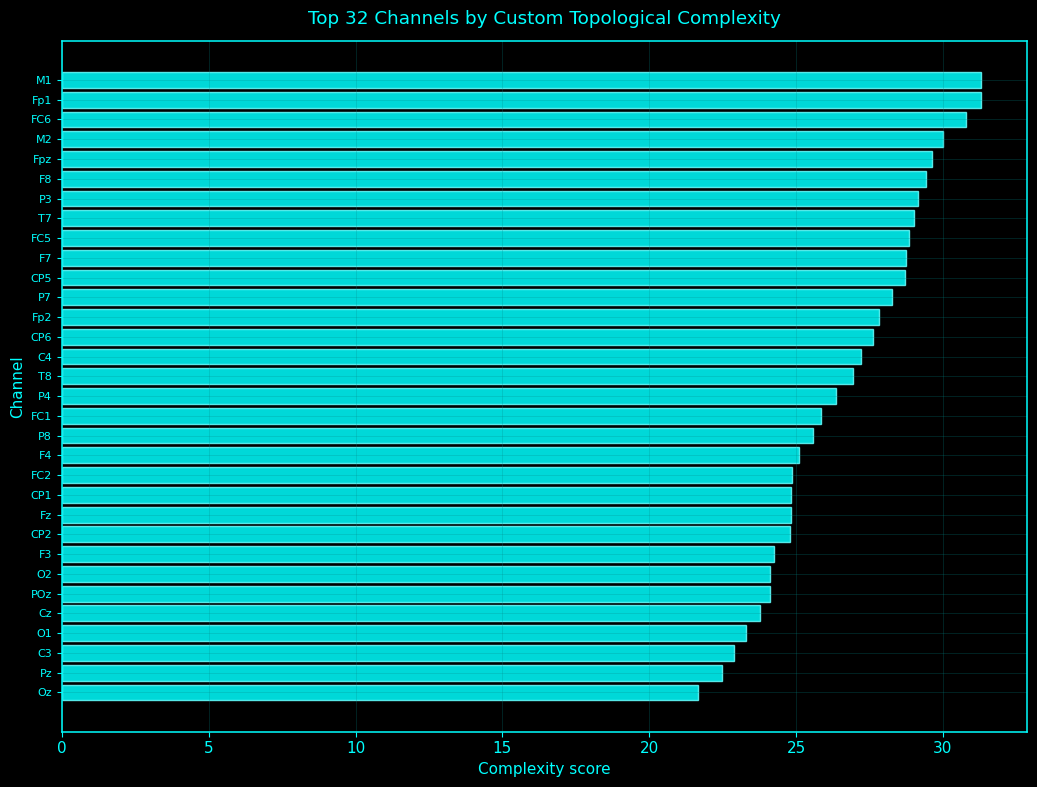

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/01_custom_topology_complexity_ranking_black_cyan.png


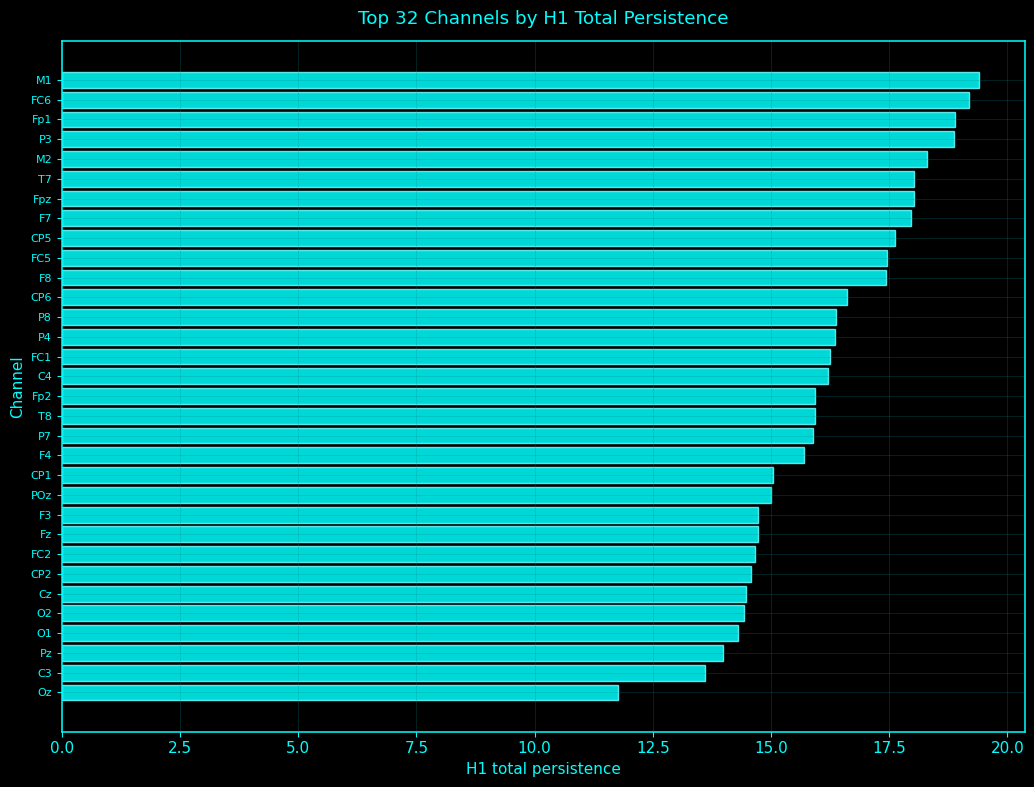

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/02_h1_total_persistence_ranking_black_cyan.png


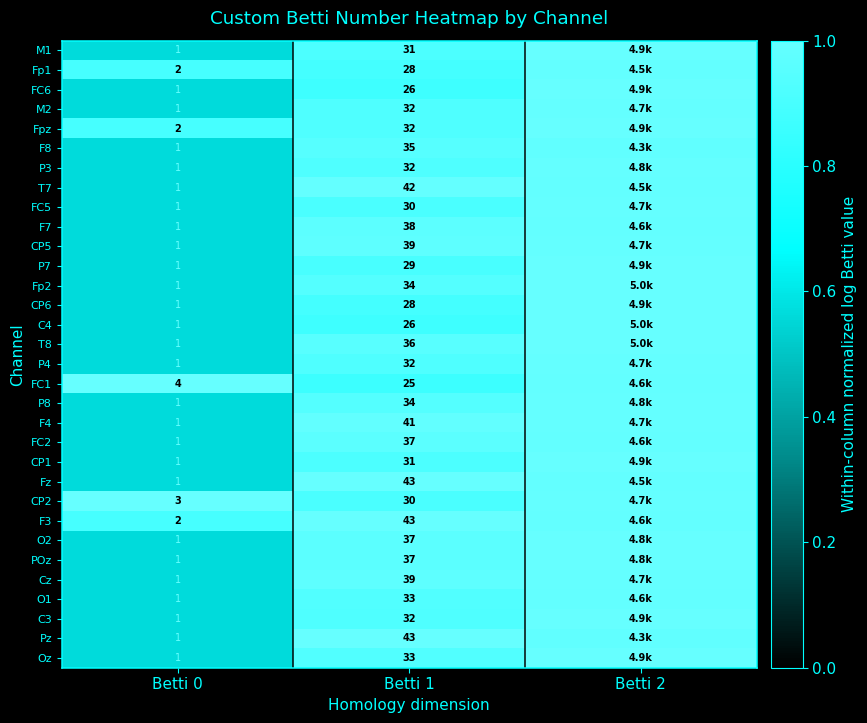

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/03_custom_betti_heatmap_fixed_height_black_cyan.png


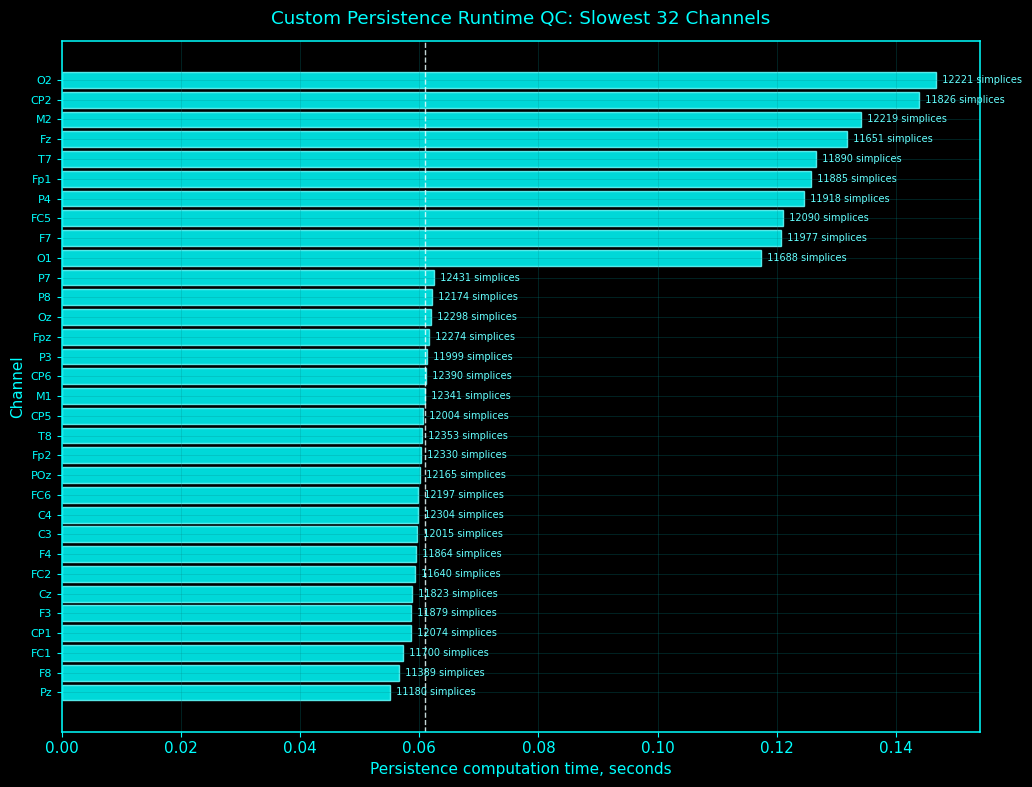

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/04_custom_persistence_runtime_qc_black_cyan.png


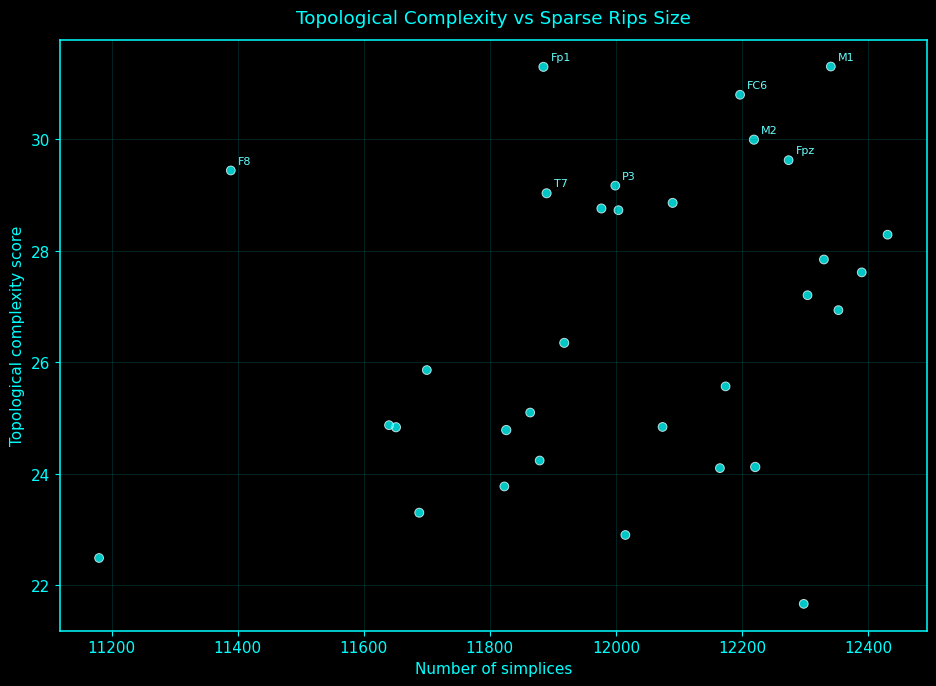

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/05_complexity_vs_sparse_rips_size_black_cyan.png


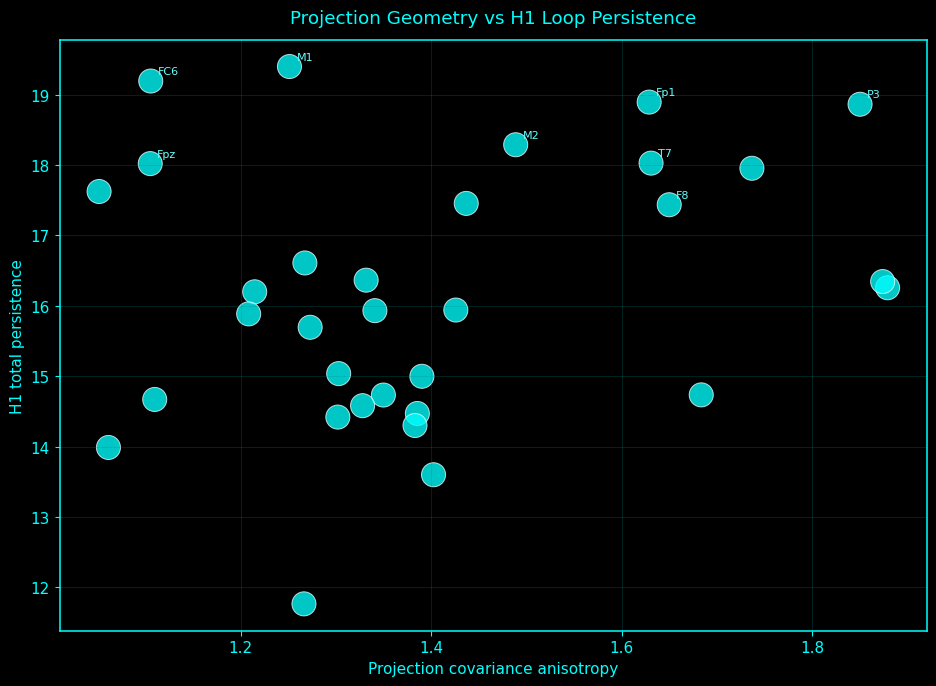

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/06_projection_geometry_vs_h1_topology_black_cyan.png


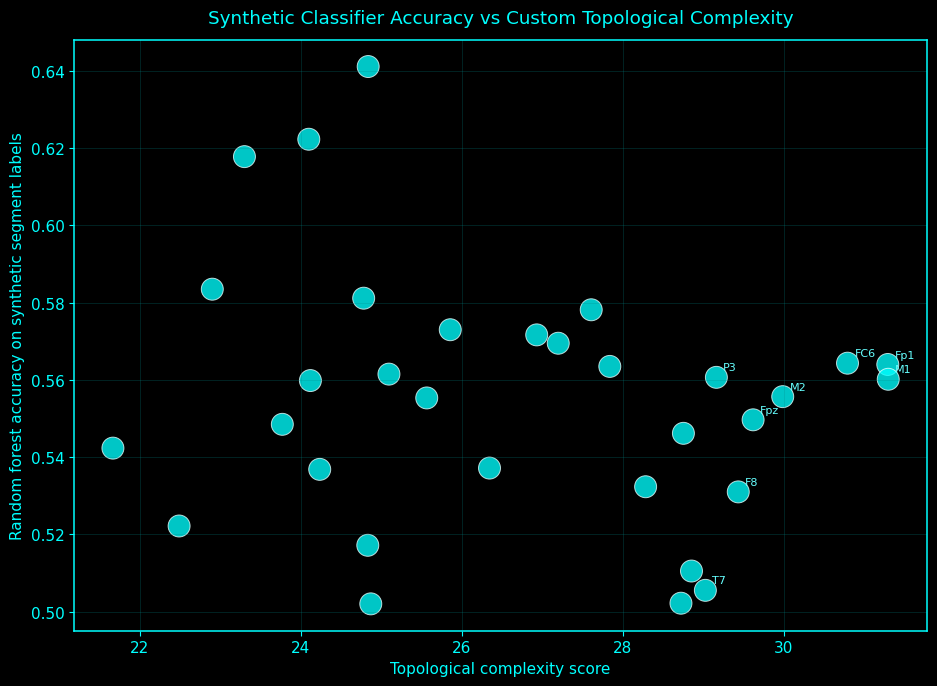

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/07_rf_accuracy_vs_topology_black_cyan.png


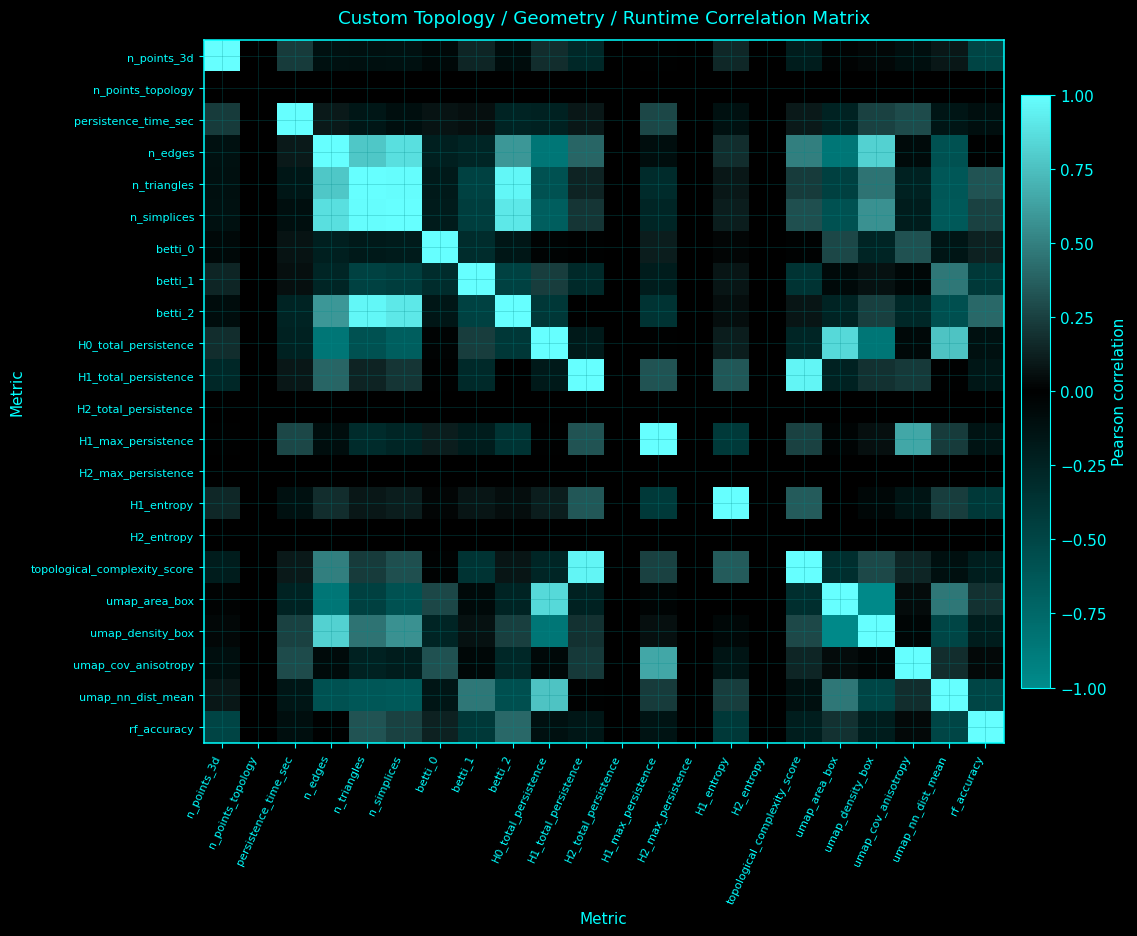

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/08_metric_correlation_matrix_black_cyan.png


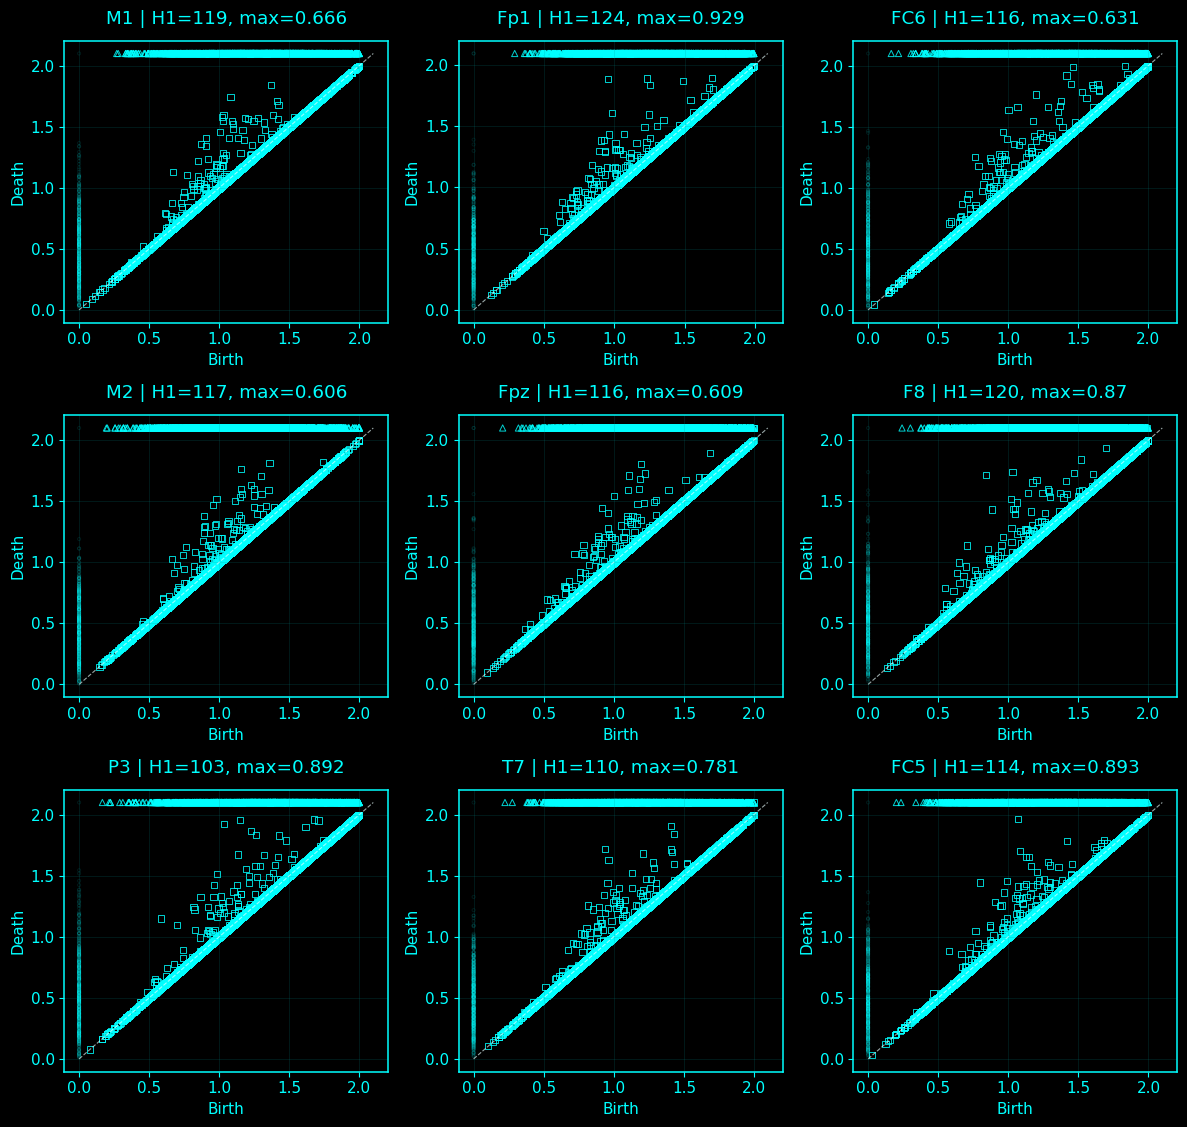

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/10_persistence_diagram_gallery_top_channels_black_cyan.png


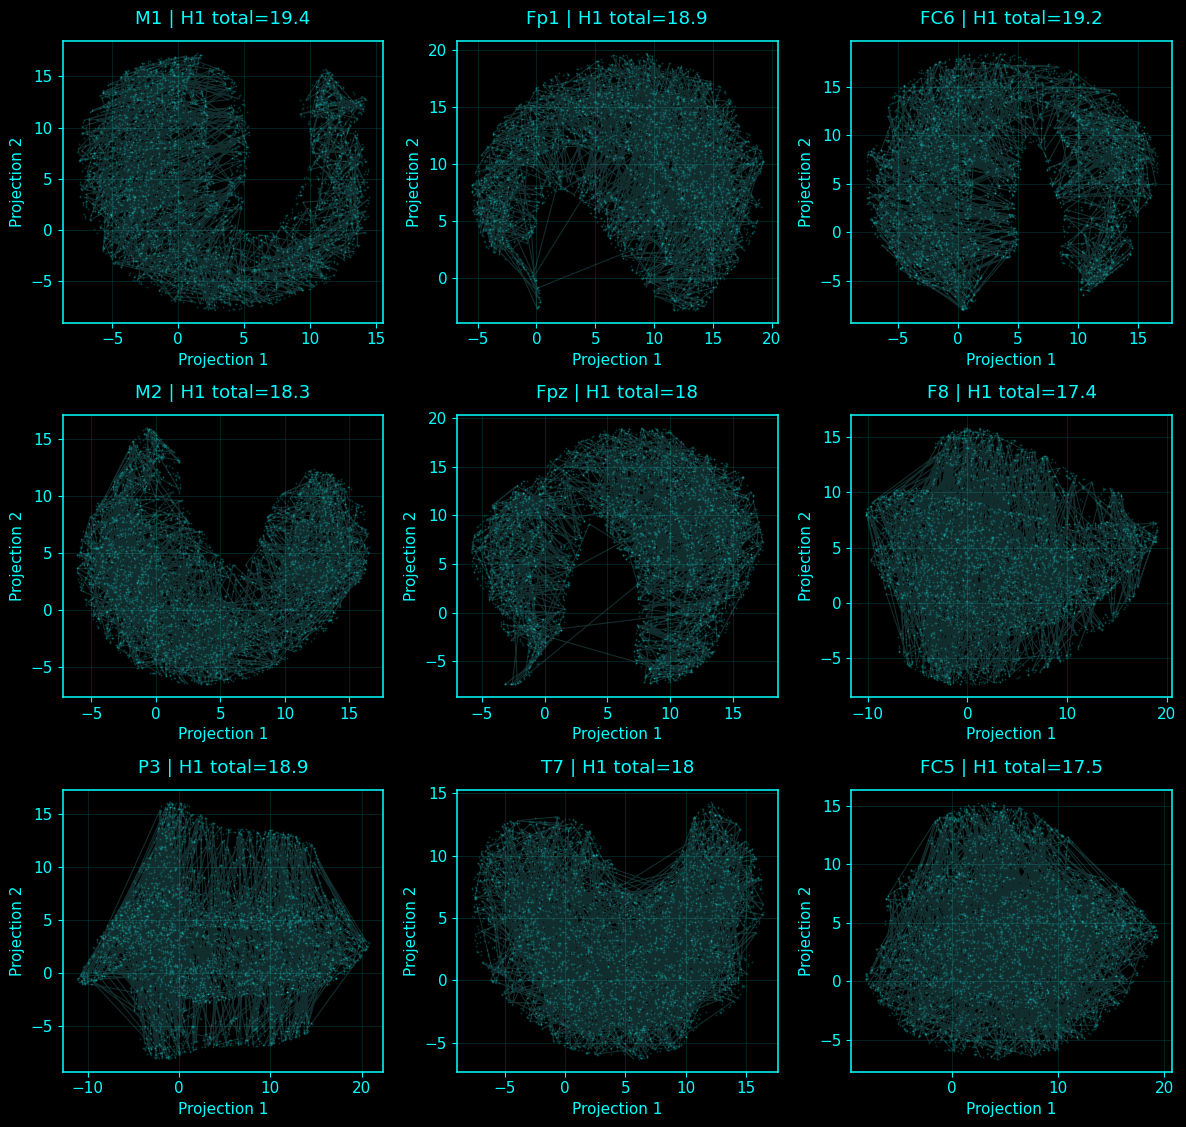

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/11_projection_gallery_top_channels_black_cyan.png


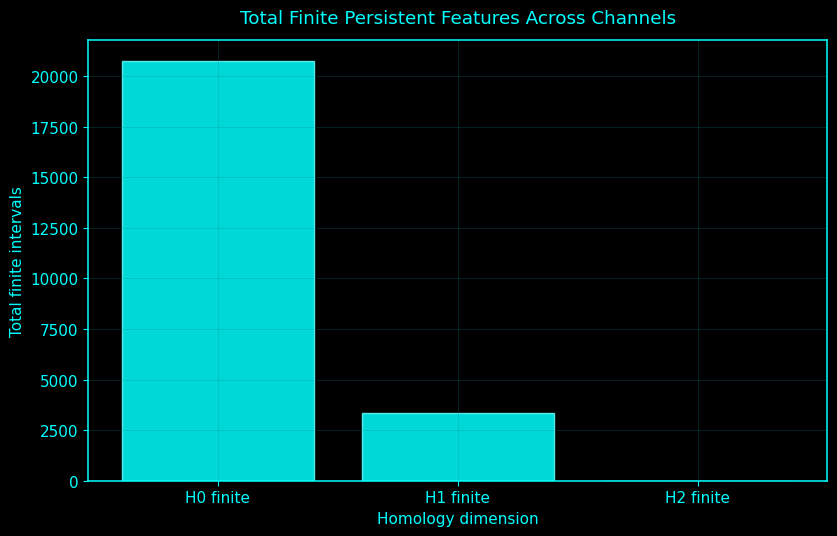

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/12_total_persistent_feature_counts_black_cyan.png


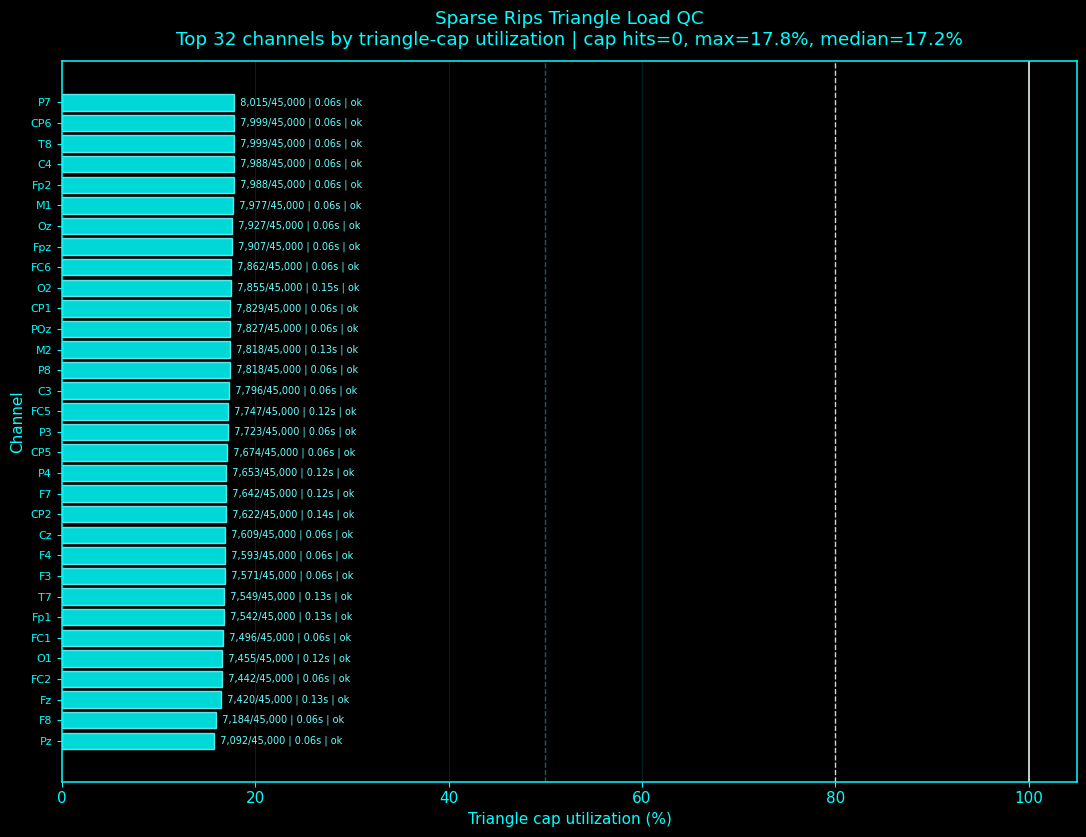

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/13_triangle_cap_qc_black_cyan.png

CUSTOM-MATH TOPOLOGY / PROJECTION SUMMARY
Successful channels: 32
FAST_OPTION: fast
Projection: PCA fallback
Persistence points per channel: 650
Sparse Rips k: 10
Rips max edge length: 2.0
Max triangles: 45000

Top 10 by custom topological complexity score:
channel  betti_0  betti_1  betti_2  H1_n_finite  H1_total_persistence  H1_max_persistence  topological_complexity_score  n_edges  n_triangles  persistence_time_sec  persistence_cache_reused  rf_accuracy
     M1        1       31     4943          119             19.401541            0.666126                     31.301541     3714         7977              0.060922                     False     0.560167
    Fp1        2       28     4525          124             18.895880            0.929328                     31.295880     3693         7542              0.125693           

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier

try:
    import umap.umap_ as umap
    _HAVE_UMAP = True
except Exception:
    umap = None
    _HAVE_UMAP = False

try:
    from sklearn.decomposition import PCA
    _HAVE_PCA = True
except Exception:
    PCA = None
    _HAVE_PCA = False

try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
reuse_umap_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d")
topology_dir = os.path.join(base_dir, "topology_from_3d_umap_custom_math_fast")
umap_cache_dir = os.path.join(topology_dir, "umap_embeddings")
persistence_dir = os.path.join(topology_dir, "custom_persistence_npz")
plot_root_dir = os.path.join(base_dir, "plots", "topology_from_3d_umap_custom_math_fast")
expert_plot_dir = os.path.join(plot_root_dir, "expert_summary_plots")
optional_per_channel_plot_dir = os.path.join(plot_root_dir, "optional_per_channel_plots")

for d in [topology_dir, umap_cache_dir, persistence_dir, plot_root_dir, expert_plot_dir, optional_per_channel_plot_dir]:
    os.makedirs(d, exist_ok=True)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

FAST_OPTION = "fast"
MAX_CHANNELS = None
REUSE_PERSISTENCE_CACHE = True
RECOMPUTE_PROJECTION = False
RUN_RANDOM_FOREST = True

if FAST_OPTION == "ultra":
    persistence_max_points = 350
    sparse_rips_k = 7
    rips_max_edge_length = 1.75
    max_triangles = 12000
    rf_estimators = 60
    rf_max_points = 12000
    umap_plot_max_points = 2500
    TOP_N_RANKED_PLOTS = 24
    TOP_N_GALLERY = 6
    TOP_N_LIFETIME_OVERLAY = 10
elif FAST_OPTION == "fast":
    persistence_max_points = 650
    sparse_rips_k = 10
    rips_max_edge_length = 2.0
    max_triangles = 45000
    rf_estimators = 90
    rf_max_points = 20000
    umap_plot_max_points = 4000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 14
elif FAST_OPTION == "balanced":
    persistence_max_points = 900
    sparse_rips_k = 14
    rips_max_edge_length = 2.0
    max_triangles = 120000
    rf_estimators = 120
    rf_max_points = 30000
    umap_plot_max_points = 5000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 16
elif FAST_OPTION == "full":
    persistence_max_points = 1500
    sparse_rips_k = 18
    rips_max_edge_length = 2.0
    max_triangles = 250000
    rf_estimators = 200
    rf_max_points = None
    umap_plot_max_points = 9000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 16
else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42
segment_length = 1000
test_size = 0.30
random_state_split = 42
rf_random_state = 42
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
SAVE_OPTIONAL_PER_CHANNEL_PLOTS = False
SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK = False

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)

def save_fig(fig, save_path, show_in_notebook=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show_in_notebook and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)

def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)
    col_mean = np.nanmean(X, axis=0, keepdims=True)
    inds = np.where(~np.isfinite(X))
    if inds[0].size > 0:
        X[inds] = np.take(col_mean, inds[1])
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows_with_indices(X, max_points=None, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    if max_points is None or n <= max_points:
        return X, np.arange(n)
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx

def make_synthetic_labels(n, segment_length=1000):
    num_segments = int(np.ceil(n / segment_length))
    labels = np.repeat(np.arange(num_segments) % 2, segment_length)[:n]
    return labels.astype(int)

def manual_train_test_split(X, y, test_size=0.3, random_state=42):
    X = np.asarray(X)
    y = np.asarray(y)
    n = len(X)
    if n < 3:
        raise ValueError("Need at least 3 samples for train/test split.")
    rng_local = np.random.default_rng(random_state)
    perm = rng_local.permutation(n)
    n_test = int(np.round(test_size * n))
    n_test = min(max(n_test, 1), n - 1)
    test_idx = perm[:n_test]
    train_idx = perm[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def manual_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return np.nan
    return float(np.mean(y_true == y_pred))

def apply_projection(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    if _HAVE_UMAP:
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="euclidean",
            random_state=random_state,
            transform_seed=random_state,
            low_memory=True,
        )
        return reducer.fit_transform(data), "UMAP"
    if _HAVE_PCA:
        reducer = PCA(n_components=n_components, random_state=random_state)
        return reducer.fit_transform(data), "PCA_fallback"
    raise ImportError("Neither umap-learn nor sklearn PCA is available.")

def load_or_compute_projection(channel_name, X_std):
    reuse_path = os.path.join(reuse_umap_dir, f"umap_embedding_{channel_name}.npy")
    if not RECOMPUTE_PROJECTION and os.path.exists(reuse_path):
        try:
            emb = np.load(reuse_path)
            emb = np.asarray(emb, dtype=float)
            if emb.ndim == 2 and emb.shape[1] == 2 and emb.shape[0] == X_std.shape[0]:
                return emb, reuse_path, 0.0, True, "reuse_previous_umap"
        except Exception:
            pass
    cache_path = os.path.join(umap_cache_dir, f"projection_embedding_{channel_name}.npy")
    if not RECOMPUTE_PROJECTION and os.path.exists(cache_path):
        try:
            emb = np.load(cache_path)
            emb = np.asarray(emb, dtype=float)
            if emb.ndim == 2 and emb.shape[1] == 2 and emb.shape[0] == X_std.shape[0]:
                return emb, cache_path, 0.0, True, "local_projection_cache"
        except Exception:
            pass
    t0 = time.perf_counter()
    emb, projection_method = apply_projection(
        X_std,
        n_components=n_components_umap,
        n_neighbors=n_neighbors_umap,
        min_dist=min_dist_umap,
        random_state=random_state_umap,
    )
    elapsed = time.perf_counter() - t0
    np.save(cache_path, emb)
    return emb, cache_path, elapsed, False, projection_method

def finite_lifetimes(intervals):
    arr = np.asarray(intervals, dtype=float)
    if arr.size == 0:
        return np.array([], dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        return np.array([], dtype=float)
    birth = arr[:, 0]
    death = arr[:, 1]
    mask = np.isfinite(birth) & np.isfinite(death) & (death > birth)
    return death[mask] - birth[mask]

def persistent_entropy(lifetimes):
    lifetimes = np.asarray(lifetimes, dtype=float)
    lifetimes = lifetimes[np.isfinite(lifetimes) & (lifetimes > 0)]
    if lifetimes.size <= 1:
        return 0.0
    p = lifetimes / np.sum(lifetimes)
    return float(-np.sum(p * np.log(p)) / np.log(len(p)))

def interval_stats(intervals):
    life = finite_lifetimes(intervals)
    if life.size == 0:
        return {"n": 0, "total": 0.0, "mean": 0.0, "max": 0.0, "q90": 0.0, "entropy": 0.0}
    return {
        "n": int(life.size),
        "total": float(np.sum(life)),
        "mean": float(np.mean(life)),
        "max": float(np.max(life)),
        "q90": float(np.quantile(life, 0.90)),
        "entropy": persistent_entropy(life),
    }

def compute_umap_geometry_metrics(emb):
    emb = np.asarray(emb, dtype=float)
    if emb.ndim != 2 or emb.shape[1] != 2 or len(emb) < 3:
        return {
            "umap_x_range": np.nan,
            "umap_y_range": np.nan,
            "umap_area_box": np.nan,
            "umap_density_box": np.nan,
            "umap_cov_anisotropy": np.nan,
            "umap_nn_dist_mean": np.nan,
            "umap_nn_dist_median": np.nan,
        }
    x_range = float(np.max(emb[:, 0]) - np.min(emb[:, 0]))
    y_range = float(np.max(emb[:, 1]) - np.min(emb[:, 1]))
    area = float(max(x_range * y_range, 1e-12))
    density = float(len(emb) / area)
    cov = np.cov(emb.T)
    eig = np.linalg.eigvalsh(cov)
    eig = np.sort(np.maximum(eig, 1e-12))
    anisotropy = float(eig[-1] / eig[0])
    if _HAVE_KDTREE:
        tree = KDTree(emb)
        dists, _ = tree.query(emb, k=2)
        nn = dists[:, 1]
    else:
        sample, _ = subsample_rows_with_indices(emb, max_points=min(2500, len(emb)), rng=np.random.default_rng(123))
        dmat = np.sqrt(np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2))
        np.fill_diagonal(dmat, np.inf)
        nn = np.min(dmat, axis=1)
    return {
        "umap_x_range": x_range,
        "umap_y_range": y_range,
        "umap_area_box": area,
        "umap_density_box": density,
        "umap_cov_anisotropy": anisotropy,
        "umap_nn_dist_mean": float(np.mean(nn)),
        "umap_nn_dist_median": float(np.median(nn)),
    }

def pairwise_edges_bruteforce(points, max_edge_length):
    points = np.asarray(points, dtype=float)
    n = len(points)
    edges = {}
    for i in range(n):
        diffs = points[i + 1:] - points[i]
        dists = np.sqrt(np.einsum("ij,ij->i", diffs, diffs))
        js = np.where(dists <= max_edge_length)[0] + i + 1
        for j, d in zip(js, dists[js - i - 1]):
            edges[(i, j)] = float(d)
    return edges

def build_sparse_rips_complex(points, max_edge_length=2.0, k=14, max_triangles=120000):
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n == 0:
        return [], [], False
    edges = {}
    if _HAVE_KDTREE and n > 1:
        tree = KDTree(points)
        qk = min(n, k + 1)
        try:
            dists, idxs = tree.query(points, k=qk, workers=-1)
        except TypeError:
            dists, idxs = tree.query(points, k=qk)
        dists = np.asarray(dists)
        idxs = np.asarray(idxs)
        if dists.ndim == 1:
            dists = dists[:, None]
            idxs = idxs[:, None]
        for i in range(n):
            for dist, j in zip(dists[i], idxs[i]):
                j = int(j)
                if j == i or j < 0 or j >= n:
                    continue
                if not np.isfinite(dist) or dist > max_edge_length:
                    continue
                a, b = sorted((i, j))
                if a != b:
                    old = edges.get((a, b), np.inf)
                    if dist < old:
                        edges[(a, b)] = float(dist)
    else:
        edges = pairwise_edges_bruteforce(points, max_edge_length=max_edge_length)
    edge_items = [(i, j, d) for (i, j), d in edges.items()]
    edge_items.sort(key=lambda x: (x[2], x[0], x[1]))
    adjacency = [set() for _ in range(n)]
    for i, j, d in edge_items:
        adjacency[i].add(j)
        adjacency[j].add(i)
    edge_len = {(i, j): d for i, j, d in edge_items}
    triangles = []
    triangle_cap_hit = False
    for i, j, dij in edge_items:
        if len(triangles) >= max_triangles:
            triangle_cap_hit = True
            break
        common = adjacency[i].intersection(adjacency[j])
        if len(common) == 0:
            continue
        for k3 in common:
            if k3 <= j:
                continue
            e1 = (min(i, j), max(i, j))
            e2 = (min(i, k3), max(i, k3))
            e3 = (min(j, k3), max(j, k3))
            if e1 not in edge_len or e2 not in edge_len or e3 not in edge_len:
                continue
            filt = max(edge_len[e1], edge_len[e2], edge_len[e3])
            if filt <= max_edge_length:
                triangles.append((i, j, k3, float(filt)))
                if len(triangles) >= max_triangles:
                    triangle_cap_hit = True
                    break
    triangles.sort(key=lambda x: (x[3], x[0], x[1], x[2]))
    return edge_items, triangles, triangle_cap_hit

def custom_persistent_homology_z2(points, max_edge_length=2.0, k=14, max_triangles=120000):
    points = np.asarray(points, dtype=float)
    n = len(points)
    edges, triangles, triangle_cap_hit = build_sparse_rips_complex(
        points,
        max_edge_length=max_edge_length,
        k=k,
        max_triangles=max_triangles,
    )
    simplices = []
    for i in range(n):
        simplices.append(((i,), 0, 0.0))
    for i, j, d in edges:
        simplices.append(((i, j), 1, float(d)))
    for i, j, k3, f in triangles:
        simplices.append(((i, j, k3), 2, float(f)))
    simplices.sort(key=lambda s: (s[2], s[1], s[0]))
    simplex_index = {s[0]: idx for idx, s in enumerate(simplices)}
    dims = np.array([s[1] for s in simplices], dtype=int)
    filtrations = np.array([s[2] for s in simplices], dtype=float)
    boundaries = []
    for vertices, dim, filt in simplices:
        if dim == 0:
            boundaries.append(set())
        elif dim == 1:
            i, j = vertices
            boundaries.append({simplex_index[(i,)], simplex_index[(j,)]})
        elif dim == 2:
            i, j, k3 = vertices
            e1 = tuple(sorted((i, j)))
            e2 = tuple(sorted((i, k3)))
            e3 = tuple(sorted((j, k3)))
            boundaries.append({simplex_index[e1], simplex_index[e2], simplex_index[e3]})
        else:
            boundaries.append(set())
    low_to_col = {}
    reduced_nonzero_cols = {}
    paired_birth_to_death = {}
    is_birth_col = np.zeros(len(simplices), dtype=bool)
    for j, boundary in enumerate(boundaries):
        col = set(boundary)
        while len(col) > 0:
            low = max(col)
            if low in low_to_col:
                col ^= reduced_nonzero_cols[low_to_col[low]]
            else:
                break
        if len(col) == 0:
            is_birth_col[j] = True
        else:
            low = max(col)
            low_to_col[low] = j
            reduced_nonzero_cols[j] = col
            paired_birth_to_death[low] = j
    intervals_by_dim = {0: [], 1: [], 2: []}
    for birth_idx, is_birth in enumerate(is_birth_col):
        if not is_birth:
            continue
        dim = int(dims[birth_idx])
        if dim not in intervals_by_dim:
            intervals_by_dim[dim] = []
        birth = float(filtrations[birth_idx])
        if birth_idx in paired_birth_to_death:
            death_idx = paired_birth_to_death[birth_idx]
            death = float(filtrations[death_idx])
        else:
            death = np.inf
        intervals_by_dim[dim].append([birth, death])
    for dim in intervals_by_dim:
        if len(intervals_by_dim[dim]) == 0:
            intervals_by_dim[dim] = np.empty((0, 2), dtype=float)
        else:
            intervals_by_dim[dim] = np.asarray(intervals_by_dim[dim], dtype=float)
    betti = []
    for dim in [0, 1, 2]:
        arr = intervals_by_dim.get(dim, np.empty((0, 2), dtype=float))
        if arr.size == 0:
            betti.append(0)
        else:
            betti.append(int(np.sum(~np.isfinite(arr[:, 1]))))
    diagnostics = {
        "n_vertices": int(n),
        "n_edges": int(len(edges)),
        "n_triangles": int(len(triangles)),
        "n_simplices": int(len(simplices)),
        "triangle_cap_hit": bool(triangle_cap_hit),
        "sparse_rips_k": int(k),
        "rips_max_edge_length": float(max_edge_length),
        "max_triangles": int(max_triangles),
    }
    return intervals_by_dim, betti, diagnostics

def persistence_cache_path(channel_name):
    cache_tag = f"custom_persistence_{channel_name}_mode-{FAST_OPTION}_n-{persistence_max_points}_k-{sparse_rips_k}_eps-{rips_max_edge_length}_tri-{max_triangles}.npz"
    cache_tag = cache_tag.replace(".", "p")
    return os.path.join(persistence_dir, cache_tag)

def load_persistence_cache(path):
    if not REUSE_PERSISTENCE_CACHE or not os.path.exists(path):
        return None
    try:
        data = np.load(path, allow_pickle=True)
        H0 = np.asarray(data["H0"], dtype=float)
        H1 = np.asarray(data["H1"], dtype=float)
        H2 = np.asarray(data["H2"], dtype=float)
        betti = np.asarray(data["betti"], dtype=int).tolist()
        ph_diag = {
            "n_vertices": int(data["n_vertices"]),
            "n_edges": int(data["n_edges"]),
            "n_triangles": int(data["n_triangles"]),
            "n_simplices": int(data["n_simplices"]),
            "triangle_cap_hit": bool(data["triangle_cap_hit"]),
            "sparse_rips_k": int(data["sparse_rips_k"]),
            "rips_max_edge_length": float(data["rips_max_edge_length"]),
            "max_triangles": int(data["max_triangles"]),
        }
        intervals_by_dim = {0: H0, 1: H1, 2: H2}
        return intervals_by_dim, betti, ph_diag
    except Exception:
        return None

def save_persistence_cache(path, intervals_by_dim, betti_numbers, topology_idx, channel_name, ph_diag):
    H0 = np.asarray(intervals_by_dim.get(0, np.empty((0, 2))), dtype=float)
    H1 = np.asarray(intervals_by_dim.get(1, np.empty((0, 2))), dtype=float)
    H2 = np.asarray(intervals_by_dim.get(2, np.empty((0, 2))), dtype=float)
    np.savez_compressed(
        path,
        H0=H0,
        H1=H1,
        H2=H2,
        betti=np.asarray(betti_numbers, dtype=int),
        n_points_topology=int(len(topology_idx)),
        topology_indices=topology_idx,
        channel=channel_name,
        n_vertices=int(ph_diag["n_vertices"]),
        n_edges=int(ph_diag["n_edges"]),
        n_triangles=int(ph_diag["n_triangles"]),
        n_simplices=int(ph_diag["n_simplices"]),
        triangle_cap_hit=bool(ph_diag["triangle_cap_hit"]),
        sparse_rips_k=int(ph_diag["sparse_rips_k"]),
        rips_max_edge_length=float(ph_diag["rips_max_edge_length"]),
        max_triangles=int(ph_diag["max_triangles"]),
    )

def fit_random_forest_diagnostic(projected_data):
    if not RUN_RANDOM_FOREST:
        return np.nan
    X_rf, _ = subsample_rows_with_indices(projected_data, max_points=rf_max_points, rng=np.random.default_rng(987))
    labels = make_synthetic_labels(len(X_rf), segment_length=segment_length)
    X_train, X_test, y_train, y_test = manual_train_test_split(
        X_rf,
        labels,
        test_size=test_size,
        random_state=random_state_split,
    )
    clf = RandomForestClassifier(
        n_estimators=rf_estimators,
        random_state=rf_random_state,
        n_jobs=-1,
        max_depth=None if FAST_OPTION in ["balanced", "full"] else 18,
        min_samples_leaf=1 if FAST_OPTION in ["balanced", "full"] else 2,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return manual_accuracy(y_test, y_pred)

def plot_persistence_diagram_manual(intervals_by_dim, channel_name, save_path, show_in_notebook=False):
    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor=BLACK)
    all_finite_deaths = []
    for dim in intervals_by_dim:
        arr = np.asarray(intervals_by_dim[dim], dtype=float)
        if arr.size == 0:
            continue
        finite_mask = np.isfinite(arr[:, 1])
        if np.any(finite_mask):
            all_finite_deaths.extend(arr[finite_mask, 1].tolist())
    max_finite = max(all_finite_deaths) if len(all_finite_deaths) > 0 else 1.0
    inf_cap = max_finite * 1.05
    markers = {0: "o", 1: "s", 2: "^"}
    for dim in range(3):
        arr = np.asarray(intervals_by_dim.get(dim, np.empty((0, 2))), dtype=float)
        if arr.size == 0:
            continue
        births = arr[:, 0]
        deaths = arr[:, 1].copy()
        deaths[~np.isfinite(deaths)] = inf_cap
        alpha = 0.18 if dim == 0 else 0.85
        size = 7 if dim == 0 else 24
        ax.scatter(
            births,
            deaths,
            s=size,
            marker=markers.get(dim, "o"),
            facecolors="none",
            edgecolors=ACCENT,
            linewidths=0.8,
            alpha=alpha,
            label=f"H{dim}",
        )
    lim = max(inf_cap, 1e-6)
    ax.plot([0, lim], [0, lim], linestyle="--", color=WHITE, alpha=0.75, linewidth=1.0)
    style_ax(ax, title=f"Custom Persistence Diagram | {channel_name}", xlabel="Birth", ylabel="Death")
    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)
    save_fig(fig, save_path, show_in_notebook=show_in_notebook)

def plot_betti_numbers(betti_numbers, channel_name, save_path, show_in_notebook=False):
    dims = [0, 1, 2]
    vals = list(betti_numbers)
    fig, ax = plt.subplots(figsize=(5.5, 4.0), facecolor=BLACK)
    ax.bar(dims, vals, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_xticks(dims)
    style_ax(ax, title=f"Custom Betti Numbers | {channel_name}", xlabel="Homology dimension", ylabel="Betti number")
    save_fig(fig, save_path, show_in_notebook=show_in_notebook)

def plot_topology_score_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["topological_complexity_score"])]
    if df.empty:
        return None
    df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    df = df.sort_values("topological_complexity_score", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["topological_complexity_score"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    style_ax(ax, title=f"Top {len(df)} Channels by Custom Topological Complexity", xlabel="Complexity score", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_h1_total_persistence_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["H1_total_persistence"])]
    if df.empty:
        return None
    df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    df = df.sort_values("H1_total_persistence", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["H1_total_persistence"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    style_ax(ax, title=f"Top {len(df)} Channels by H1 Total Persistence", xlabel="H1 total persistence", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_betti_heatmap(summary_df, save_path):
    df = summary_df.copy()
    needed = ["betti_0", "betti_1", "betti_2"]
    for c in needed:
        if c not in df.columns:
            return None
    if "topological_complexity_score" in df.columns:
        df = df.sort_values("topological_complexity_score", ascending=False)
    elif "H1_total_persistence" in df.columns:
        df = df.sort_values("H1_total_persistence", ascending=False)
    raw = df[needed].to_numpy(dtype=float)
    if raw.size == 0:
        return None
    log_raw = np.log1p(np.maximum(raw, 0))
    display_matrix = np.zeros_like(log_raw, dtype=float)
    for j in range(log_raw.shape[1]):
        col = log_raw[:, j]
        finite = col[np.isfinite(col)]
        if finite.size == 0:
            continue
        vmax = np.nanpercentile(finite, 95)
        vmax = max(vmax, 1e-12)
        display_matrix[:, j] = np.clip(col / vmax, 0, 1)
    betti_cmap = LinearSegmentedColormap.from_list("betti_black_cyan", [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT], N=256)
    fig_height = min(8.5, max(6.0, 0.23 * len(df)))
    fig, ax = plt.subplots(figsize=(8.8, fig_height))
    im = ax.imshow(display_matrix, aspect="auto", interpolation="nearest", cmap=betti_cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(["Betti 0", "Betti 1", "Betti 2"], color=ACCENT)
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels([short_label(x, 18) for x in df["channel"]], color=ACCENT, fontsize=8)
    for i in range(raw.shape[0]):
        for j in range(raw.shape[1]):
            val = raw[i, j]
            if not np.isfinite(val):
                label = "NA"
            elif abs(val) >= 1000:
                label = f"{val/1000:.1f}k"
            else:
                label = f"{int(round(val))}"
            text_color = BLACK if display_matrix[i, j] > 0.62 else ACCENT_SOFT
            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=7, fontweight="bold" if display_matrix[i, j] > 0.62 else "normal")
    style_ax(ax, title="Custom Betti Number Heatmap by Channel", xlabel="Homology dimension", ylabel="Channel")
    ax.grid(False)
    for x in [0.5, 1.5]:
        ax.axvline(x, color=BLACK, linewidth=1.2, alpha=0.9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Within-column normalized log Betti value", color=ACCENT)
    save_fig(fig, save_path)
    return save_path

def plot_runtime_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["persistence_time_sec"])]
    if df.empty:
        return None
    df = df.sort_values("persistence_time_sec", ascending=False).head(top_n)
    df = df.sort_values("persistence_time_sec", ascending=True)
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["persistence_time_sec"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels([short_label(x, 22) for x in df["channel"]], color=ACCENT, fontsize=8)
    med = df["persistence_time_sec"].median()
    ax.axvline(med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.85)
    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(row["persistence_time_sec"], yi, f"  {int(row['n_simplices'])} simplices", va="center", ha="left", color=ACCENT_SOFT, fontsize=7)
    style_ax(ax, title=f"Custom Persistence Runtime QC: Slowest {len(df)} Channels", xlabel="Persistence computation time, seconds", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_complexity_vs_simplices(summary_df, save_path):
    df = summary_df.copy()
    df = df[np.isfinite(df["n_simplices"]) & np.isfinite(df["topological_complexity_score"]) & np.isfinite(df["persistence_time_sec"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(30 + 100 * df["persistence_time_sec"].to_numpy(), 40, 300)
    ax.scatter(df["n_simplices"], df["topological_complexity_score"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["n_simplices"], r["topological_complexity_score"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Topological Complexity vs Sparse Rips Size", xlabel="Number of simplices", ylabel="Topological complexity score")
    save_fig(fig, save_path)
    return save_path

def plot_umap_geometry_vs_topology(summary_df, save_path):
    df = summary_df.copy()
    required = ["umap_cov_anisotropy", "H1_total_persistence", "topological_complexity_score"]
    for c in required:
        if c not in df.columns:
            return None
    df = df[np.isfinite(df["umap_cov_anisotropy"]) & np.isfinite(df["H1_total_persistence"]) & np.isfinite(df["topological_complexity_score"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(60 + 35 * df["topological_complexity_score"].to_numpy(), 40, 300)
    ax.scatter(df["umap_cov_anisotropy"], df["H1_total_persistence"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["umap_cov_anisotropy"], r["H1_total_persistence"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Projection Geometry vs H1 Loop Persistence", xlabel="Projection covariance anisotropy", ylabel="H1 total persistence")
    save_fig(fig, save_path)
    return save_path

def plot_rf_accuracy_vs_topology(summary_df, save_path):
    df = summary_df.copy()
    df = df[np.isfinite(df["rf_accuracy"]) & np.isfinite(df["topological_complexity_score"]) & np.isfinite(df["H1_total_persistence"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(40 + 80 * df["H1_total_persistence"].to_numpy(), 40, 250)
    ax.scatter(df["topological_complexity_score"], df["rf_accuracy"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["topological_complexity_score"], r["rf_accuracy"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Synthetic Classifier Accuracy vs Custom Topological Complexity", xlabel="Topological complexity score", ylabel="Random forest accuracy on synthetic segment labels")
    save_fig(fig, save_path)
    return save_path

def plot_metric_correlation_matrix(summary_df, save_path):
    metric_cols = [
        "n_points_3d", "n_points_topology", "persistence_time_sec", "n_edges", "n_triangles", "n_simplices",
        "betti_0", "betti_1", "betti_2", "H0_total_persistence", "H1_total_persistence", "H2_total_persistence",
        "H1_max_persistence", "H2_max_persistence", "H1_entropy", "H2_entropy", "topological_complexity_score",
        "umap_area_box", "umap_density_box", "umap_cov_anisotropy", "umap_nn_dist_mean", "rf_accuracy",
    ]
    metric_cols = [c for c in metric_cols if c in summary_df.columns]
    if len(metric_cols) < 3:
        return None
    M = summary_df[metric_cols].apply(pd.to_numeric, errors="coerce")
    corr = M.corr()
    if corr.empty:
        return None
    fig, ax = plt.subplots(figsize=(11.5, 9.5))
    im = ax.imshow(corr.to_numpy(), aspect="auto", interpolation="nearest", cmap=CYAN_DIVERGING_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=65, ha="right", color=ACCENT, fontsize=8)
    ax.set_yticklabels(metric_cols, color=ACCENT, fontsize=8)
    style_ax(ax, title="Custom Topology / Geometry / Runtime Correlation Matrix", xlabel="Metric", ylabel="Metric")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Pearson correlation", color=ACCENT)
    save_fig(fig, save_path)
    return save_path

def plot_h1_lifetime_overlay(summary_df, save_path, top_n=16):
    df = summary_df.copy()
    df = df[np.isfinite(df["H1_total_persistence"])]
    df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10.5, 7.0))
    plotted = 0
    for rank, (_, row) in enumerate(df.iterrows(), start=1):
        npz_path = row.get("persistence_path_abs", "")
        if not isinstance(npz_path, str) or not os.path.exists(npz_path):
            continue
        data = np.load(npz_path)
        H1 = np.asarray(data["H1"], dtype=float)
        life = finite_lifetimes(H1)
        life = life[np.isfinite(life) & (life > 0)]
        if life.size < 3:
            continue
        life = np.sort(life)[::-1]
        x = np.arange(1, len(life) + 1)
        alpha = max(0.25, 1.0 - 0.04 * rank)
        lw = 2.4 if rank <= 5 else 1.4
        ax.plot(x, life, color=ACCENT, linewidth=lw, alpha=alpha)
        if rank <= 8:
            ax.text(x[-1] + 0.15, life[-1], str(row["channel"]), color=ACCENT_SOFT, fontsize=8, va="center")
        plotted += 1
    if plotted == 0:
        plt.close(fig)
        return None
    style_ax(ax, title=f"H1 Lifetime Spectra Overlay: Top {plotted} Channels", xlabel="H1 feature rank, sorted by lifetime", ylabel="Persistence lifetime: death - birth")
    save_fig(fig, save_path)
    return save_path

def plot_persistence_diagram_gallery(summary_df, save_path, top_n=9):
    def _resolve_persistence_path(row):
        candidates = []

        p = row.get("persistence_path_abs", None)
        if isinstance(p, str) and len(p) > 0:
            candidates.append(p)

        f = row.get("persistence_file", None)
        if isinstance(f, str) and len(f) > 0:
            candidates.append(os.path.join(persistence_dir, f))

        ch = row.get("channel", None)

        if isinstance(ch, str) and len(ch) > 0:
            try:
                candidates.append(persistence_cache_path(ch))
            except Exception:
                pass

            candidates.extend([
                os.path.join(persistence_dir, f"custom_persistence_{ch}.npz"),
                os.path.join(persistence_dir, f"persistence_{ch}.npz"),
                os.path.join(persistence_dir, f"custom_persistence_{ch}_mode-{FAST_OPTION}_n-{persistence_max_points}_k-{sparse_rips_k}_eps-{str(rips_max_edge_length).replace('.', 'p')}_tri-{max_triangles}.npz"),
            ])

            try:
                import glob
                patterns = [
                    os.path.join(persistence_dir, f"custom_persistence_{ch}*.npz"),
                    os.path.join(persistence_dir, f"*persistence*{ch}*.npz"),
                    os.path.join(persistence_dir, f"*{ch}*.npz"),
                ]

                for pat in patterns:
                    matches = sorted(glob.glob(pat), key=lambda x: os.path.getmtime(x), reverse=True)
                    candidates.extend(matches)
            except Exception:
                pass

        seen = set()

        for cand in candidates:
            if not isinstance(cand, str):
                continue

            if cand in seen:
                continue

            seen.add(cand)

            if os.path.exists(cand):
                try:
                    data = np.load(cand)

                    if ("H0" in data.files) and ("H1" in data.files) and ("H2" in data.files):
                        return cand
                except Exception:
                    continue

        return None

    df = summary_df.copy()

    if "topological_complexity_score" in df.columns:
        df = df[np.isfinite(df["topological_complexity_score"])]
        df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    elif "H1_total_persistence" in df.columns:
        df = df[np.isfinite(df["H1_total_persistence"])]
        df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    else:
        df = df.head(top_n)

    if df.empty:
        return None

    resolved_paths = []

    for _, row in df.iterrows():
        resolved_paths.append(_resolve_persistence_path(row))

    df = df.copy()
    df["_resolved_persistence_path"] = resolved_paths

    has_any = df["_resolved_persistence_path"].notna().any()

    if not has_any:
        print(
            "Persistence gallery skipped: no usable .npz persistence files found. "
            "Check persistence_dir, FAST_OPTION, or rerun with REUSE_PERSISTENCE_CACHE=False once.",
            flush=True,
        )
        return None

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    markers = {0: "o", 1: "s", 2: "^"}

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")

        npz_path = row.get("_resolved_persistence_path", None)
        channel = row.get("channel", "unknown")

        if not isinstance(npz_path, str) or not os.path.exists(npz_path):
            ax.text(
                0.5,
                0.5,
                "No persistence file found",
                color=ACCENT_SOFT,
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
            )

            style_ax(
                ax,
                title=f"{channel} | file not found",
                xlabel="Birth",
                ylabel="Death",
            )

            continue

        try:
            data = np.load(npz_path)

            intervals_by_dim = {
                0: np.asarray(data["H0"], dtype=float),
                1: np.asarray(data["H1"], dtype=float),
                2: np.asarray(data["H2"], dtype=float),
            }

        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"Could not read npz\n{type(e).__name__}",
                color=ACCENT_SOFT,
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=9,
            )

            style_ax(
                ax,
                title=f"{channel} | read error",
                xlabel="Birth",
                ylabel="Death",
            )

            continue

        all_finite_deaths = []

        for dim, arr in intervals_by_dim.items():
            if arr.size == 0:
                continue

            if arr.ndim != 2 or arr.shape[1] != 2:
                continue

            finite_mask = np.isfinite(arr[:, 1])

            if np.any(finite_mask):
                all_finite_deaths.extend(arr[finite_mask, 1].tolist())

        max_finite = max(all_finite_deaths) if len(all_finite_deaths) > 0 else 1.0
        inf_cap = max_finite * 1.05

        plotted_any = False

        for dim in range(3):
            arr = intervals_by_dim.get(dim, np.empty((0, 2)),)

            if arr.size == 0:
                continue

            if arr.ndim != 2 or arr.shape[1] != 2:
                continue

            births = arr[:, 0]
            deaths = arr[:, 1].copy()
            deaths[~np.isfinite(deaths)] = inf_cap

            alpha = 0.10 if dim == 0 else 0.82
            size = 5 if dim == 0 else 20

            ax.scatter(
                births,
                deaths,
                s=size,
                marker=markers.get(dim, "o"),
                facecolors="none",
                edgecolors=ACCENT,
                linewidths=0.7,
                alpha=alpha,
                label=f"H{dim}",
            )

            plotted_any = True

        lim = max(inf_cap, 1e-6)

        ax.plot(
            [0, lim],
            [0, lim],
            linestyle="--",
            color=WHITE,
            alpha=0.65,
            linewidth=0.8,
        )

        if plotted_any:
            h1_life = finite_lifetimes(intervals_by_dim.get(1, np.empty((0, 2))))
            h2_life = finite_lifetimes(intervals_by_dim.get(2, np.empty((0, 2))))

            title = (
                f"{channel} | "
                f"H1={len(h1_life)}, max={np.max(h1_life) if len(h1_life) else 0:.3g}"
            )

            if len(h2_life):
                title += f" | H2={len(h2_life)}"
        else:
            title = f"{channel} | empty intervals"

        style_ax(
            ax,
            title=title,
            xlabel="Birth",
            ylabel="Death",
        )

        ax.grid(True, alpha=0.18, color=ACCENT_DIM)

    save_fig(fig, save_path)

    return save_path

def plot_projection_gallery(summary_df, save_path, top_n=9):
    df = summary_df.copy()
    df = df[np.isfinite(df["topological_complexity_score"])]
    df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    if df.empty:
        return None
    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)
    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")
    local_rng = np.random.default_rng(123)
    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        projection_path = row.get("projection_path_abs", "")
        if not isinstance(projection_path, str) or not os.path.exists(projection_path):
            ax.set_title(f"{row['channel']} | missing projection", color=ACCENT)
            continue
        emb = np.load(projection_path)
        emb = np.asarray(emb, dtype=float)
        emb_plot, idx = subsample_rows_with_indices(emb, max_points=umap_plot_max_points, rng=local_rng)
        ax.scatter(emb_plot[:, 0], emb_plot[:, 1], s=1.8, c=ACCENT, alpha=0.22, linewidths=0)
        step = max(1, len(emb_plot) // 1000)
        ax.plot(emb_plot[::step, 0], emb_plot[::step, 1], color=ACCENT_SOFT, alpha=0.18, linewidth=0.8)
        style_ax(ax, title=f"{row['channel']} | H1 total={row['H1_total_persistence']:.3g}", xlabel="Projection 1", ylabel="Projection 2")
    save_fig(fig, save_path)
    return save_path

def plot_persistent_feature_counts(summary_df, save_path):
    df = summary_df.copy()
    count_cols = ["H0_n_finite", "H1_n_finite", "H2_n_finite"]
    count_cols = [c for c in count_cols if c in df.columns]
    if len(count_cols) == 0:
        return None
    totals = df[count_cols].sum(axis=0)
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    labels = ["H0 finite", "H1 finite", "H2 finite"][:len(totals)]
    ax.bar(labels, totals.values, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    style_ax(ax, title="Total Finite Persistent Features Across Channels", xlabel="Homology dimension", ylabel="Total finite intervals")
    save_fig(fig, save_path)
    return save_path

def plot_triangle_cap_flags(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    required = ["channel", "n_triangles", "max_triangles", "triangle_cap_hit"]
    for c in required:
        if c not in df.columns:
            return None
    df = df[np.isfinite(df["n_triangles"]) & np.isfinite(df["max_triangles"]) & (df["max_triangles"] > 0)].copy()
    if df.empty:
        return None
    df["triangle_cap_utilization_pct"] = 100.0 * df["n_triangles"] / df["max_triangles"]
    if "n_edges" in df.columns:
        df["triangles_per_edge"] = df["n_triangles"] / np.maximum(df["n_edges"], 1)
    else:
        df["triangles_per_edge"] = np.nan
    if "persistence_time_sec" in df.columns:
        df["persistence_time_sec"] = pd.to_numeric(df["persistence_time_sec"], errors="coerce")
    else:
        df["persistence_time_sec"] = np.nan
    df = df.sort_values("triangle_cap_utilization_pct", ascending=False).head(top_n)
    df = df.sort_values("triangle_cap_utilization_pct", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig_height = min(8.5, max(6.0, 0.27 * len(df)))
    fig, ax = plt.subplots(figsize=(11.0, fig_height))
    bar_colors = []
    edge_colors = []
    for hit in df["triangle_cap_hit"].astype(bool).to_numpy():
        if hit:
            bar_colors.append(ACCENT_SOFT)
            edge_colors.append(WHITE)
        else:
            bar_colors.append(ACCENT)
            edge_colors.append(ACCENT_SOFT)
    ax.barh(y, df["triangle_cap_utilization_pct"], color=bar_colors, edgecolor=edge_colors, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    ax.axvline(50, color=ACCENT_DIM, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axvline(80, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.85)
    ax.axvline(100, color=WHITE, linestyle="-", linewidth=1.2, alpha=0.95)
    for yi, (_, row) in zip(y, df.iterrows()):
        cap_label = "CAP" if bool(row["triangle_cap_hit"]) else "ok"
        tri_label = f"{int(row['n_triangles']):,}/{int(row['max_triangles']):,}"
        time_val = row.get("persistence_time_sec", np.nan)
        label = f"  {tri_label} | {time_val:.2f}s | {cap_label}" if np.isfinite(time_val) else f"  {tri_label} | {cap_label}"
        ax.text(row["triangle_cap_utilization_pct"], yi, label, va="center", ha="left", color=ACCENT_SOFT, fontsize=7)
    cap_hits = int(df["triangle_cap_hit"].astype(bool).sum())
    max_util = float(df["triangle_cap_utilization_pct"].max())
    median_util = float(df["triangle_cap_utilization_pct"].median())
    style_ax(
        ax,
        title=(
            "Sparse Rips Triangle Load QC\n"
            f"Top {len(df)} channels by triangle-cap utilization | cap hits={cap_hits}, max={max_util:.1f}%, median={median_util:.1f}%"
        ),
        xlabel="Triangle cap utilization (%)",
        ylabel="Channel",
    )
    ax.set_xlim(0, max(105, df["triangle_cap_utilization_pct"].max() * 1.18))
    ax.grid(True, axis="x", alpha=0.25, color=ACCENT_DIM)
    ax.grid(False, axis="y")
    save_fig(fig, save_path)
    return save_path

def make_expert_plots(summary_df):
    plot_paths = []
    plot_specs = [
        (plot_topology_score_ranking, os.path.join(expert_plot_dir, "01_custom_topology_complexity_ranking_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_h1_total_persistence_ranking, os.path.join(expert_plot_dir, "02_h1_total_persistence_ranking_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_betti_heatmap, os.path.join(expert_plot_dir, "03_custom_betti_heatmap_fixed_height_black_cyan.png"), {}),
        (plot_runtime_ranking, os.path.join(expert_plot_dir, "04_custom_persistence_runtime_qc_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_complexity_vs_simplices, os.path.join(expert_plot_dir, "05_complexity_vs_sparse_rips_size_black_cyan.png"), {}),
        (plot_umap_geometry_vs_topology, os.path.join(expert_plot_dir, "06_projection_geometry_vs_h1_topology_black_cyan.png"), {}),
        (plot_rf_accuracy_vs_topology, os.path.join(expert_plot_dir, "07_rf_accuracy_vs_topology_black_cyan.png"), {}),
        (plot_metric_correlation_matrix, os.path.join(expert_plot_dir, "08_metric_correlation_matrix_black_cyan.png"), {}),
        (plot_h1_lifetime_overlay, os.path.join(expert_plot_dir, "09_h1_lifetime_overlay_black_cyan.png"), {"top_n": TOP_N_LIFETIME_OVERLAY}),
        (plot_persistence_diagram_gallery, os.path.join(expert_plot_dir, "10_persistence_diagram_gallery_top_channels_black_cyan.png"), {"top_n": TOP_N_GALLERY}),
        (plot_projection_gallery, os.path.join(expert_plot_dir, "11_projection_gallery_top_channels_black_cyan.png"), {"top_n": TOP_N_GALLERY}),
        (plot_persistent_feature_counts, os.path.join(expert_plot_dir, "12_total_persistent_feature_counts_black_cyan.png"), {}),
        (plot_triangle_cap_flags, os.path.join(expert_plot_dir, "13_triangle_cap_qc_black_cyan.png"), {}),
    ]
    for fn, path, kwargs in plot_specs:
        try:
            result = fn(summary_df, path, **kwargs)
            if result is not None:
                plot_paths.append(result)
                print(f"Saved plot: {result}", flush=True)
        except Exception as e:
            print(f"Plot failed: {fn.__name__} | {type(e).__name__}: {e}", flush=True)
    return plot_paths

def save_summary_text(summary_df, summary_txt):
    with open(summary_txt, "w") as f:
        f.write("Custom-math topology from 3D embeddings after projection\n")
        f.write("======================================================\n\n")
        f.write("Persistent homology implementation: custom sparse Vietoris-Rips over Z2\n")
        f.write("H0 is graph-component persistence on the sparse Rips graph.\n")
        f.write("H1 is computed from edges and triangle boundaries using column reduction over Z2.\n")
        f.write("H2 is estimated from zero-reduced triangle columns; no tetrahedra are used, so H2 is conservative/diagnostic.\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"embedding_3d_dir: {embedding_3d_dir}\n")
        f.write(f"reuse_umap_dir: {reuse_umap_dir}\n")
        f.write(f"topology_dir: {topology_dir}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"REUSE_PERSISTENCE_CACHE: {REUSE_PERSISTENCE_CACHE}\n")
        f.write(f"projection_method_available_umap: {_HAVE_UMAP}\n")
        f.write(f"projection_method_available_pca: {_HAVE_PCA}\n")
        f.write(f"persistence_max_points: {persistence_max_points}\n")
        f.write(f"sparse_rips_k: {sparse_rips_k}\n")
        f.write(f"rips_max_edge_length: {rips_max_edge_length}\n")
        f.write(f"max_triangles: {max_triangles}\n")
        f.write(f"segment_length: {segment_length}\n")
        f.write(f"test_size: {test_size}\n")
        f.write(f"rf_estimators: {rf_estimators}\n")
        f.write(f"rf_max_points: {rf_max_points}\n\n")
        if len(summary_df) > 0:
            f.write("Per-channel summary:\n")
            for _, row in summary_df.iterrows():
                f.write(
                    f"{row['channel']}: "
                    f"Betti=({row['betti_0']},{row['betti_1']},{row['betti_2']}), "
                    f"H0/H1/H2 finite=({row['H0_n_finite']},{row['H1_n_finite']},{row['H2_n_finite']}), "
                    f"H1_total={row['H1_total_persistence']:.6g}, "
                    f"H1_max={row['H1_max_persistence']:.6g}, "
                    f"score={row['topological_complexity_score']:.6g}, "
                    f"edges={row['n_edges']}, "
                    f"triangles={row['n_triangles']}, "
                    f"simplices={row['n_simplices']}, "
                    f"triangle_cap_hit={row['triangle_cap_hit']}, "
                    f"RF_acc={row['rf_accuracy']:.4f}, "
                    f"projection_source={row['projection_source_type']}, "
                    f"projection_time={row['projection_time_sec']:.2f}s, "
                    f"persistence_time={row['persistence_time_sec']:.2f}s, "
                    f"cache_reused={row['persistence_cache_reused']}\n"
                )

def print_expert_console_summary(summary_df):
    print("\n" + "=" * 92, flush=True)
    print("CUSTOM-MATH TOPOLOGY / PROJECTION SUMMARY", flush=True)
    print("=" * 92, flush=True)
    if summary_df.empty:
        print("No successful channels.", flush=True)
        return
    print(f"Successful channels: {len(summary_df)}", flush=True)
    print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
    print(f"Projection: {'UMAP' if _HAVE_UMAP else 'PCA fallback'}", flush=True)
    print(f"Persistence points per channel: {persistence_max_points}", flush=True)
    print(f"Sparse Rips k: {sparse_rips_k}", flush=True)
    print(f"Rips max edge length: {rips_max_edge_length}", flush=True)
    print(f"Max triangles: {max_triangles}", flush=True)
    cols = [
        "channel", "betti_0", "betti_1", "betti_2", "H1_n_finite", "H1_total_persistence",
        "H1_max_persistence", "topological_complexity_score", "n_edges", "n_triangles",
        "persistence_time_sec", "persistence_cache_reused", "rf_accuracy",
    ]
    cols = [c for c in cols if c in summary_df.columns]
    print("\nTop 10 by custom topological complexity score:", flush=True)
    print(summary_df.sort_values("topological_complexity_score", ascending=False)[cols].head(10).to_string(index=False), flush=True)
    print("\nTop 10 by H1 total persistence:", flush=True)
    print(summary_df.sort_values("H1_total_persistence", ascending=False)[cols].head(10).to_string(index=False), flush=True)
    print("\nRuntime summary:", flush=True)
    runtime_cols = [
        "channel", "persistence_time_sec", "n_edges", "n_triangles", "n_simplices",
        "triangle_cap_hit", "n_points_topology", "projection_reused", "projection_time_sec",
        "persistence_cache_reused",
    ]
    runtime_cols = [c for c in runtime_cols if c in summary_df.columns]
    print(summary_df.sort_values("persistence_time_sec", ascending=False)[runtime_cols].head(10).to_string(index=False), flush=True)

summary_rows = []
channels_to_process = eeg_channel_names[:MAX_CHANNELS] if MAX_CHANNELS is not None else eeg_channel_names

print("Running custom-math topology from 3D projection pipeline", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"GUDHI used: False", flush=True)
print(f"UMAP available: {_HAVE_UMAP}", flush=True)
print(f"PCA fallback available: {_HAVE_PCA}", flush=True)
print(f"cKDTree available: {_HAVE_KDTREE}", flush=True)
print(f"Notebook plot display: {SHOW_PLOTS_IN_NOTEBOOK}", flush=True)
print(f"Save plots to disk: {SAVE_PLOTS_TO_DISK}", flush=True)
print(f"Optional per-channel plots enabled: {SAVE_OPTIONAL_PER_CHANNEL_PLOTS}", flush=True)
print(f"Persistence cache reuse: {REUSE_PERSISTENCE_CACHE}", flush=True)
print(f"Channels to process: {len(channels_to_process)}", flush=True)

pipeline_start = time.perf_counter()

for_channel_count = len(channels_to_process)

for channel_idx, channel_name in enumerate(channels_to_process, start=1):
    channel_start = time.perf_counter()
    file_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")
    if not os.path.exists(file_path):
        print(f"Missing file for {channel_name}: {file_path}", flush=True)
        continue
    try:
        channel_data_3d = np.load(file_path)
        channel_data_3d = np.asarray(channel_data_3d, dtype=float)
        if channel_data_3d.ndim != 2 or channel_data_3d.shape[1] != 3:
            print(f"Skipping {channel_name}: expected shape (N, 3), got {channel_data_3d.shape}", flush=True)
            continue
        X3 = standardize_columns(channel_data_3d)
        print(f"\n[{channel_idx}/{for_channel_count}] Processing {channel_name} | 3D shape={X3.shape}", flush=True)
        projected_data, projection_path_used, projection_time, projection_reused, projection_source_type = load_or_compute_projection(channel_name, X3)
        if projected_data.ndim != 2 or projected_data.shape[1] != 2:
            print(f"Skipping {channel_name}: bad projection shape {projected_data.shape}", flush=True)
            continue
        geom = compute_umap_geometry_metrics(projected_data)
        reduced_topology, topology_idx = subsample_rows_with_indices(projected_data, max_points=persistence_max_points, rng=rng)
        persistence_npz_path = persistence_cache_path(channel_name)
        cached = load_persistence_cache(persistence_npz_path)
        persistence_cache_reused = cached is not None
        if cached is not None:
            t0 = time.perf_counter()
            intervals_by_dim, betti_numbers, ph_diag = cached
            persistence_time = time.perf_counter() - t0
        else:
            t0 = time.perf_counter()
            intervals_by_dim, betti_numbers, ph_diag = custom_persistent_homology_z2(
                reduced_topology,
                max_edge_length=rips_max_edge_length,
                k=sparse_rips_k,
                max_triangles=max_triangles,
            )
            persistence_time = time.perf_counter() - t0
            save_persistence_cache(persistence_npz_path, intervals_by_dim, betti_numbers, topology_idx, channel_name, ph_diag)
        H0 = np.asarray(intervals_by_dim.get(0, np.empty((0, 2))), dtype=float)
        H1 = np.asarray(intervals_by_dim.get(1, np.empty((0, 2))), dtype=float)
        H2 = np.asarray(intervals_by_dim.get(2, np.empty((0, 2))), dtype=float)
        if SAVE_OPTIONAL_PER_CHANNEL_PLOTS:
            persistence_plot_path = os.path.join(optional_per_channel_plot_dir, f"Custom_Persistence_{channel_name}.png")
            plot_persistence_diagram_manual(intervals_by_dim, channel_name, persistence_plot_path, show_in_notebook=SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK)
            betti_plot_path = os.path.join(optional_per_channel_plot_dir, f"Custom_Betti_{channel_name}.png")
            plot_betti_numbers(betti_numbers, channel_name, betti_plot_path, show_in_notebook=SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK)
        accuracy = fit_random_forest_diagnostic(projected_data)
        H0_stats = interval_stats(H0)
        H1_stats = interval_stats(H1)
        H2_stats = interval_stats(H2)
        topological_complexity_score = (
            H1_stats["total"]
            + 0.50 * H2_stats["total"]
            + 0.10 * H1_stats["n"]
            + 0.05 * H2_stats["n"]
        )
        channel_elapsed = time.perf_counter() - channel_start
        print(f"Custom Betti numbers for {channel_name}: {tuple(betti_numbers)}", flush=True)
        print(f"H1 total persistence for {channel_name}: {H1_stats['total']:.6g}", flush=True)
        print(f"Topological complexity score for {channel_name}: {topological_complexity_score:.6g}", flush=True)
        print(f"Edges / triangles / simplices: {ph_diag['n_edges']} / {ph_diag['n_triangles']} / {ph_diag['n_simplices']}", flush=True)
        print(f"Triangle cap hit: {ph_diag['triangle_cap_hit']}", flush=True)
        print(f"Model accuracy for {channel_name}: {accuracy:.4f}", flush=True)
        print(f"Persistence cache reused: {persistence_cache_reused}", flush=True)
        print(f"Persistence time for {channel_name}: {persistence_time:.3f}s", flush=True)
        print(f"Channel elapsed time for {channel_name}: {channel_elapsed:.3f}s", flush=True)
        row = {
            "channel": channel_name,
            "n_points_3d": int(X3.shape[0]),
            "n_points_projection": int(projected_data.shape[0]),
            "n_points_topology": int(reduced_topology.shape[0]),
            "projection_reused": bool(projection_reused),
            "projection_source_type": projection_source_type,
            "projection_time_sec": float(projection_time),
            "persistence_time_sec": float(persistence_time),
            "persistence_cache_reused": bool(persistence_cache_reused),
            "channel_elapsed_sec": float(channel_elapsed),
            "n_vertices": int(ph_diag["n_vertices"]),
            "n_edges": int(ph_diag["n_edges"]),
            "n_triangles": int(ph_diag["n_triangles"]),
            "n_simplices": int(ph_diag["n_simplices"]),
            "triangle_cap_hit": bool(ph_diag["triangle_cap_hit"]),
            "sparse_rips_k": int(ph_diag["sparse_rips_k"]),
            "rips_max_edge_length": float(ph_diag["rips_max_edge_length"]),
            "max_triangles": int(ph_diag["max_triangles"]),
            "betti_0": int(betti_numbers[0]),
            "betti_1": int(betti_numbers[1]),
            "betti_2": int(betti_numbers[2]),
            "n_H0_intervals": int(len(H0)),
            "n_H1_intervals": int(len(H1)),
            "n_H2_intervals": int(len(H2)),
            "H0_n_finite": H0_stats["n"],
            "H0_total_persistence": H0_stats["total"],
            "H0_mean_persistence": H0_stats["mean"],
            "H0_max_persistence": H0_stats["max"],
            "H0_q90_persistence": H0_stats["q90"],
            "H0_entropy": H0_stats["entropy"],
            "H1_n_finite": H1_stats["n"],
            "H1_total_persistence": H1_stats["total"],
            "H1_mean_persistence": H1_stats["mean"],
            "H1_max_persistence": H1_stats["max"],
            "H1_q90_persistence": H1_stats["q90"],
            "H1_entropy": H1_stats["entropy"],
            "H2_n_finite": H2_stats["n"],
            "H2_total_persistence": H2_stats["total"],
            "H2_mean_persistence": H2_stats["mean"],
            "H2_max_persistence": H2_stats["max"],
            "H2_q90_persistence": H2_stats["q90"],
            "H2_entropy": H2_stats["entropy"],
            "topological_complexity_score": float(topological_complexity_score),
            "rf_accuracy": float(accuracy),
            "projection_source": os.path.basename(projection_path_used),
            "projection_path_abs": projection_path_used,
            "persistence_file": os.path.basename(persistence_npz_path),
            "persistence_path_abs": persistence_npz_path,
        }
        row.update(geom)
        summary_rows.append(row)
    except Exception as e:
        print(f"ERROR processing {channel_name}: {type(e).__name__}: {e}", flush=True)

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(topology_dir, f"custom_topology_summary_from_3d_projection_{FAST_OPTION}.csv")
summary_txt = os.path.join(topology_dir, f"custom_topology_summary_from_3d_projection_{FAST_OPTION}.txt")

summary_df.to_csv(summary_csv, index=False)
save_summary_text(summary_df, summary_txt)

if len(summary_df) > 0:
    print("\nGenerating custom-math expert black/cyan plots...", flush=True)
    plot_paths = make_expert_plots(summary_df)
else:
    plot_paths = []

pipeline_elapsed = time.perf_counter() - pipeline_start

print_expert_console_summary(summary_df)
print("\nSaved summary CSV:", summary_csv, flush=True)
print("Saved summary TXT:", summary_txt, flush=True)
print("\nSaved expert plots:", flush=True)

for p in plot_paths:
    print(" ", p, flush=True)

print(f"\nTotal pipeline elapsed time: {pipeline_elapsed / 60:.2f} min", flush=True)
print("Done.", flush=True)

### Weighted Undirected Network

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis leverages graph theory to investigate the structural properties of EEG data. By constructing a weighted graph from the EEG correlation matrix, we can compute various network metrics to understand the connectivity and modularity of brain activity.</p>
        <h2>Graph Construction</h2>
        <p>The first step involves standardizing the EEG data using z-scores and then calculating the correlation matrix to quantify the relationships between EEG channels.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the z-scored value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
        <p>The correlation matrix is then computed:</p>
        \[
        R_{ij} = \frac{\text{Cov}(Z_i, Z_j)}{\sigma_{Z_i} \sigma_{Z_j}}
        \]
        <p>We construct a weighted graph \(G\) from the correlation matrix by adding nodes for each EEG channel and edges weighted by the correlation values that exceed a threshold.</p>
        <h2>Clustering Coefficient</h2>
        <p>The clustering coefficient measures the degree to which nodes in the graph tend to cluster together. It is given by:</p>
        <p><strong>Formula:</strong></p>
        \[
        C = \frac{1}{N} \sum_{i=1}^{N} \frac{2e_i}{k_i(k_i-1)}
        \]
        where \(e_i\) is the number of edges connecting the neighbors of node \(i\), and \(k_i\) is the degree of node \(i\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Modularity</h2>
        <p>Modularity quantifies the strength of division of a network into communities. Higher modularity indicates a stronger community structure.</p>
        <p><strong>Formula:</strong></p>
        \[
        Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)
        \]
        where \(A_{ij}\) is the adjacency matrix, \(k_i\) and \(k_j\) are the degrees of nodes \(i\) and \(j\), \(m\) is the number of edges, and \(\delta\) is the Kronecker delta function indicating whether nodes \(i\) and \(j\) are in the same community.</p>
        <h2>Small-Worldness</h2>
        <p>Small-world properties are assessed using two metrics: sigma (\(\sigma\)) and omega (\(\omega\)).</p>
        <p><strong>Formula:</strong></p>
m        \[
        \sigma = \frac{C / C_{\text{rand}}}{L / L_{\text{rand}}}
        \]
        \[
        \omega = \frac{L_{\text{rand}}}{L} - \frac{C}{C_{\text{latt}}}
        \]
        where \(C\) and \(L\) are the clustering coefficient and average shortest path length of the network, \(C_{\text{rand}}\) and \(L_{\text{rand}}\) are those of a random network, and \(C_{\text{latt}}\) is the clustering coefficient of a lattice network.</p>
        <h2>Global Efficiency</h2>
        <p>Global efficiency measures how efficiently information is exchanged over the network. It is the average of the inverse shortest path length.</p>
        <p><strong>Formula:</strong></p>
        \[
        E_{\text{glob}} = \frac{1}{N(N-1)} \sum_{i \neq j} \frac{1}{d_{ij}}
        \]
        where \(d_{ij}\) is the shortest path length between nodes \(i\) and \(j\).</p>
        <h2>Assortativity</h2>
        <p>Assortativity measures the tendency of nodes to connect with similar nodes. It is computed as the Pearson correlation coefficient of degrees between pairs of linked nodes.</p>
        <p><strong>Formula:</strong></p>
        \[
        r = \frac{\sum_{jk} jk(e_{jk} - q_j q_k)}{\sigma_q^2}
        \]
        where \(e_{jk}\) is the joint probability distribution of the degrees of nodes at either end of a link, and \(q_j\) is the distribution of the remaining degree.</p>
        <h2>Results and Conclusion</h2>
        <p>After computing these metrics, we gain insights into the structural properties of the EEG network. The clustering coefficient indicates local connectivity, modularity reveals community structure, small-worldness metrics compare the EEG network to idealized networks, global efficiency assesses information exchange, and assortativity reveals connectivity patterns.</p>
        <p>This graph-theoretical analysis provides a comprehensive framework for understanding the complex interactions within the brain, as captured by EEG data.</p>
    </div>
</div>


In [2]:
import os
import time
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.assortativity import degree_assortativity_coefficient

try:
    from scipy.stats import zscore
    _HAVE_SCIPY_ZSCORE = True
except Exception:
    zscore = None
    _HAVE_SCIPY_ZSCORE = False

try:
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import linkage, leaves_list
    _HAVE_SCIPY_CLUSTER = True
except Exception:
    squareform = None
    linkage = None
    leaves_list = None
    _HAVE_SCIPY_CLUSTER = False

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_data_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

results_dir = os.path.join(base_dir, "results", "eeg_graph_theory_expert")
plots_dir = os.path.join(base_dir, "plots", "eeg_graph_theory_expert")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

FAST_OPTION = "fast"
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

if FAST_OPTION == "ultra":
    threshold = 0.55
    threshold_grid = np.round(np.linspace(0.25, 0.75, 11), 3)
    n_random_smallworld = 6
    random_swap_factor = 4
    n_layout_iterations = 400
    run_threshold_sweep = True
    run_smallworld = True
    run_bootstrap = False
    bootstrap_windows = 8
elif FAST_OPTION == "fast":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.20, 0.80, 16), 3)
    n_random_smallworld = 12
    random_swap_factor = 8
    n_layout_iterations = 800
    run_threshold_sweep = True
    run_smallworld = True
    run_bootstrap = True
    bootstrap_windows = 12
elif FAST_OPTION == "balanced":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.15, 0.85, 29), 3)
    n_random_smallworld = 25
    random_swap_factor = 12
    n_layout_iterations = 1200
    run_threshold_sweep = True
    run_smallworld = True
    run_bootstrap = True
    bootstrap_windows = 20
elif FAST_OPTION == "full":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.10, 0.90, 41), 3)
    n_random_smallworld = 50
    random_swap_factor = 20
    n_layout_iterations = 2000
    run_threshold_sweep = True
    run_smallworld = True
    run_bootstrap = True
    bootstrap_windows = 32
else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

sampling_rate = 1000
start_time = 814.571
end_time = 921.515

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6", "P7",
    "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"
GRAY = "#263A3A"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    if grid:
        ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)


def short_label(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def safe_zscore(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)
    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))
    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd


def load_eeg_segment():
    EEG_data = np.load(EEG_data_path, allow_pickle=True)
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected EEG_data to be 2D, got shape {EEG_data.shape}")

    n_channels = min(EEG_data.shape[1], len(eeg_channel_names))
    EEG_data = EEG_data[:, :n_channels]
    channel_names = eeg_channel_names[:n_channels]

    start_index = int(start_time * sampling_rate)
    end_index = int(end_time * sampling_rate)

    start_index = max(0, start_index)
    end_index = min(EEG_data.shape[0], end_index)

    if end_index <= start_index:
        raise ValueError(
            f"Invalid segment indices: start={start_index}, end={end_index}, "
            f"data length={EEG_data.shape[0]}"
        )

    EEG_segment = EEG_data[start_index:end_index, :]

    return EEG_segment, channel_names, start_index, end_index


def compute_corr_matrix(EEG_segment):
    EEG_z = safe_zscore(EEG_segment)
    C = np.corrcoef(EEG_z.T)
    C = np.asarray(C, dtype=float)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = np.clip(C, -1.0, 1.0)
    np.fill_diagonal(C, 1.0)
    return EEG_z, C


def graph_from_corr(corr_matrix, channel_names, threshold=0.5, use_absolute=True, keep_sign=True):
    G = nx.Graph()

    for ch in channel_names:
        G.add_node(ch)

    n = len(channel_names)

    for i in range(n):
        for j in range(i + 1, n):
            r = float(corr_matrix[i, j])
            score = abs(r) if use_absolute else r

            if score >= threshold:
                if keep_sign:
                    edge_weight = abs(r)
                    signed_weight = r
                else:
                    edge_weight = abs(r)
                    signed_weight = abs(r)

                distance = 1.0 / (edge_weight + 1e-12)

                G.add_edge(
                    channel_names[i],
                    channel_names[j],
                    weight=edge_weight,
                    signed_weight=signed_weight,
                    correlation=r,
                    abs_correlation=abs(r),
                    distance=distance,
                    sign=1 if r >= 0 else -1,
                )

    return G


def positive_negative_graphs(corr_matrix, channel_names, threshold=0.5):
    G_pos = nx.Graph()
    G_neg = nx.Graph()

    for ch in channel_names:
        G_pos.add_node(ch)
        G_neg.add_node(ch)

    n = len(channel_names)

    for i in range(n):
        for j in range(i + 1, n):
            r = float(corr_matrix[i, j])

            if r >= threshold:
                G_pos.add_edge(
                    channel_names[i],
                    channel_names[j],
                    weight=r,
                    signed_weight=r,
                    correlation=r,
                    distance=1.0 / (abs(r) + 1e-12),
                )

            if r <= -threshold:
                G_neg.add_edge(
                    channel_names[i],
                    channel_names[j],
                    weight=abs(r),
                    signed_weight=r,
                    correlation=r,
                    distance=1.0 / (abs(r) + 1e-12),
                )

    return G_pos, G_neg


def largest_component_subgraph(G):
    if G.number_of_nodes() == 0:
        return G.copy()
    if G.number_of_edges() == 0:
        return G.copy()
    comps = list(nx.connected_components(G))
    if len(comps) == 0:
        return G.copy()
    largest = max(comps, key=len)
    return G.subgraph(largest).copy()


def weighted_average_clustering_signed_safe(G):
    if G.number_of_edges() == 0:
        return np.nan
    try:
        return float(nx.average_clustering(G, weight="weight"))
    except Exception:
        return np.nan


def average_shortest_path_safe(G, weighted=False):
    if G.number_of_edges() == 0:
        return np.nan

    H = largest_component_subgraph(G)

    if H.number_of_nodes() < 2 or H.number_of_edges() == 0:
        return np.nan

    try:
        if weighted:
            return float(nx.average_shortest_path_length(H, weight="distance"))
        return float(nx.average_shortest_path_length(H))
    except Exception:
        return np.nan


def diameter_safe(G):
    if G.number_of_edges() == 0:
        return np.nan

    H = largest_component_subgraph(G)

    if H.number_of_nodes() < 2:
        return np.nan

    try:
        return float(nx.diameter(H))
    except Exception:
        return np.nan


def transitivity_safe(G):
    try:
        return float(nx.transitivity(G))
    except Exception:
        return np.nan


def modularity_safe(G):
    if G.number_of_edges() == 0:
        return np.nan, []

    try:
        communities = list(greedy_modularity_communities(G, weight="weight"))
        q = float(modularity(G, communities, weight="weight"))
        return q, communities
    except Exception:
        return np.nan, []


def assortativity_safe(G):
    if G.number_of_edges() == 0:
        return np.nan

    try:
        val = degree_assortativity_coefficient(G)
        if not np.isfinite(val):
            return np.nan
        return float(val)
    except Exception:
        return np.nan


def local_efficiency_safe(G):
    if G.number_of_edges() == 0:
        return np.nan

    try:
        return float(nx.local_efficiency(G))
    except Exception:
        return np.nan


def global_efficiency_safe(G):
    if G.number_of_edges() == 0:
        return np.nan

    try:
        return float(nx.global_efficiency(G))
    except Exception:
        return np.nan


def graph_density_safe(G):
    try:
        return float(nx.density(G))
    except Exception:
        return np.nan


def degree_strength_table(G, channel_names):
    rows = []

    degree_dict = dict(G.degree())
    strength_dict = dict(G.degree(weight="weight"))

    try:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight") if G.number_of_edges() > 0 else {n: np.nan for n in G.nodes()}
    except Exception:
        eigenvector = {n: np.nan for n in G.nodes()}

    try:
        betweenness = nx.betweenness_centrality(G, weight="distance") if G.number_of_edges() > 0 else {n: np.nan for n in G.nodes()}
    except Exception:
        betweenness = {n: np.nan for n in G.nodes()}

    try:
        closeness = nx.closeness_centrality(G, distance="distance") if G.number_of_edges() > 0 else {n: np.nan for n in G.nodes()}
    except Exception:
        closeness = {n: np.nan for n in G.nodes()}

    try:
        pagerank = nx.pagerank(G, weight="weight") if G.number_of_edges() > 0 else {n: np.nan for n in G.nodes()}
    except Exception:
        pagerank = {n: np.nan for n in G.nodes()}

    clustering = nx.clustering(G, weight="weight") if G.number_of_edges() > 0 else {n: np.nan for n in G.nodes()}

    for ch in channel_names:
        rows.append({
            "channel": ch,
            "degree": int(degree_dict.get(ch, 0)),
            "strength": float(strength_dict.get(ch, 0.0)),
            "clustering": float(clustering.get(ch, np.nan)),
            "betweenness": float(betweenness.get(ch, np.nan)),
            "closeness": float(closeness.get(ch, np.nan)),
            "eigenvector": float(eigenvector.get(ch, np.nan)),
            "pagerank": float(pagerank.get(ch, np.nan)),
        })

    df = pd.DataFrame(rows)

    centrality_cols = ["degree", "strength", "clustering", "betweenness", "closeness", "eigenvector", "pagerank"]

    for c in centrality_cols:
        vals = df[c].to_numpy(dtype=float)
        finite = vals[np.isfinite(vals)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            df[c + "_rank_score"] = 0.0
        else:
            df[c + "_rank_score"] = (vals - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)

    df["hub_score"] = (
        0.30 * df["strength_rank_score"]
        + 0.25 * df["degree_rank_score"]
        + 0.20 * df["eigenvector_rank_score"]
        + 0.15 * df["pagerank_rank_score"]
        + 0.10 * df["betweenness_rank_score"]
    )

    return df.sort_values("hub_score", ascending=False)


def community_table(communities):
    rows = []
    for idx, comm in enumerate(communities, start=1):
        for ch in sorted(list(comm)):
            rows.append({"channel": ch, "community": idx, "community_size": len(comm)})
    return pd.DataFrame(rows)


def random_reference_metrics(G, n_random=20, swap_factor=10, seed=42):
    if G.number_of_edges() == 0 or G.number_of_nodes() < 4:
        return {
            "C_rand_mean": np.nan,
            "L_rand_mean": np.nan,
            "C_rand_std": np.nan,
            "L_rand_std": np.nan,
            "n_random_success": 0,
        }

    base = nx.Graph()
    base.add_nodes_from(G.nodes())
    base.add_edges_from(G.edges())

    m = base.number_of_edges()
    nswap = max(1, swap_factor * m)
    max_tries = max(100, nswap * 20)

    C_vals = []
    L_vals = []

    local_rng = np.random.default_rng(seed)

    for b in range(n_random):
        H = base.copy()
        try:
            nx.double_edge_swap(
                H,
                nswap=nswap,
                max_tries=max_tries,
                seed=int(local_rng.integers(0, 1_000_000_000)),
            )
        except Exception:
            pass

        C_vals.append(transitivity_safe(H))
        L_vals.append(average_shortest_path_safe(H, weighted=False))

    C_vals = np.asarray(C_vals, dtype=float)
    L_vals = np.asarray(L_vals, dtype=float)

    C_vals = C_vals[np.isfinite(C_vals)]
    L_vals = L_vals[np.isfinite(L_vals)]

    return {
        "C_rand_mean": float(np.mean(C_vals)) if C_vals.size else np.nan,
        "L_rand_mean": float(np.mean(L_vals)) if L_vals.size else np.nan,
        "C_rand_std": float(np.std(C_vals)) if C_vals.size else np.nan,
        "L_rand_std": float(np.std(L_vals)) if L_vals.size else np.nan,
        "n_random_success": int(min(C_vals.size, L_vals.size)),
    }


def lattice_reference_metrics(G):
    if G.number_of_edges() == 0 or G.number_of_nodes() < 4:
        return {"C_latt": np.nan, "L_latt": np.nan}

    n = G.number_of_nodes()
    m = G.number_of_edges()
    k = int(round(2 * m / n))

    if k < 2:
        k = 2

    if k >= n:
        k = n - 1

    if k % 2 == 1:
        k = max(2, k - 1)

    try:
        H = nx.watts_strogatz_graph(n=n, k=k, p=0, seed=42)
        return {
            "C_latt": transitivity_safe(H),
            "L_latt": average_shortest_path_safe(H, weighted=False),
        }
    except Exception:
        return {"C_latt": np.nan, "L_latt": np.nan}


def custom_smallworld_metrics(G, n_random=20, swap_factor=10):
    C = transitivity_safe(G)
    L = average_shortest_path_safe(G, weighted=False)

    rand = random_reference_metrics(G, n_random=n_random, swap_factor=swap_factor)
    latt = lattice_reference_metrics(G)

    C_rand = rand["C_rand_mean"]
    L_rand = rand["L_rand_mean"]
    C_latt = latt["C_latt"]

    sigma_val = np.nan
    omega_val = np.nan

    if np.isfinite(C) and np.isfinite(L) and np.isfinite(C_rand) and np.isfinite(L_rand):
        if C_rand > 0 and L_rand > 0 and L > 0:
            sigma_val = float((C / C_rand) / (L / L_rand))

    if np.isfinite(L_rand) and np.isfinite(L) and np.isfinite(C) and np.isfinite(C_latt):
        if L > 0 and C_latt > 0:
            omega_val = float((L_rand / L) - (C / C_latt))

    out = {
        "small_world_sigma": sigma_val,
        "small_world_omega": omega_val,
        "C": C,
        "L": L,
    }

    out.update(rand)
    out.update(latt)

    return out


def graph_metrics(G, threshold_value=np.nan, label="abs"):
    q, communities = modularity_safe(G)

    degrees = np.array([d for _, d in G.degree()], dtype=float)
    strengths = np.array([s for _, s in G.degree(weight="weight")], dtype=float)

    if G.number_of_nodes() > 0:
        n_components = nx.number_connected_components(G)
        largest_component_size = len(max(nx.connected_components(G), key=len)) if G.number_of_edges() > 0 else 1
    else:
        n_components = np.nan
        largest_component_size = np.nan

    out = {
        "label": label,
        "threshold": float(threshold_value),
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "density": graph_density_safe(G),
        "n_components": int(n_components) if np.isfinite(n_components) else np.nan,
        "largest_component_size": int(largest_component_size) if np.isfinite(largest_component_size) else np.nan,
        "mean_degree": float(np.mean(degrees)) if degrees.size else np.nan,
        "median_degree": float(np.median(degrees)) if degrees.size else np.nan,
        "max_degree": float(np.max(degrees)) if degrees.size else np.nan,
        "mean_strength": float(np.mean(strengths)) if strengths.size else np.nan,
        "median_strength": float(np.median(strengths)) if strengths.size else np.nan,
        "max_strength": float(np.max(strengths)) if strengths.size else np.nan,
        "weighted_clustering": weighted_average_clustering_signed_safe(G),
        "transitivity": transitivity_safe(G),
        "modularity": q,
        "n_communities": len(communities),
        "global_efficiency": global_efficiency_safe(G),
        "local_efficiency": local_efficiency_safe(G),
        "assortativity": assortativity_safe(G),
        "avg_shortest_path_unweighted_lcc": average_shortest_path_safe(G, weighted=False),
        "avg_shortest_path_weighted_lcc": average_shortest_path_safe(G, weighted=True),
        "diameter_lcc": diameter_safe(G),
    }

    if run_smallworld:
        out.update(custom_smallworld_metrics(G, n_random=n_random_smallworld, swap_factor=random_swap_factor))
    else:
        out.update({
            "small_world_sigma": np.nan,
            "small_world_omega": np.nan,
            "C": np.nan,
            "L": np.nan,
            "C_rand_mean": np.nan,
            "L_rand_mean": np.nan,
            "C_rand_std": np.nan,
            "L_rand_std": np.nan,
            "n_random_success": 0,
            "C_latt": np.nan,
            "L_latt": np.nan,
        })

    return out, communities


def threshold_sweep_metrics(corr_matrix, channel_names, thresholds):
    rows = []

    for th in thresholds:
        G_abs = graph_from_corr(corr_matrix, channel_names, threshold=th, use_absolute=True, keep_sign=True)
        row, _ = graph_metrics(G_abs, threshold_value=th, label="absolute")
        rows.append(row)

    return pd.DataFrame(rows)


def density_sweep_thresholds(corr_matrix, densities):
    vals = []
    n = corr_matrix.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(abs(float(corr_matrix[i, j])))

    vals = np.asarray(vals, dtype=float)

    out = []

    for d in densities:
        d = float(d)
        if d <= 0:
            out.append(1.0)
        elif d >= 1:
            out.append(0.0)
        else:
            out.append(float(np.quantile(vals, 1.0 - d)))

    return np.asarray(out)


def minimum_spanning_tree_backbone(corr_matrix, channel_names):
    G_full = nx.Graph()

    for ch in channel_names:
        G_full.add_node(ch)

    n = len(channel_names)

    for i in range(n):
        for j in range(i + 1, n):
            r = float(corr_matrix[i, j])
            abs_r = abs(r)
            distance = 1.0 - abs_r
            G_full.add_edge(
                channel_names[i],
                channel_names[j],
                weight=distance,
                display_weight=abs_r,
                correlation=r,
                abs_correlation=abs_r,
                sign=1 if r >= 0 else -1,
            )

    T = nx.minimum_spanning_tree(G_full, weight="weight")

    for u, v, data in T.edges(data=True):
        data["weight"] = data.get("display_weight", 1.0)
        data["distance"] = 1.0 / (data["weight"] + 1e-12)

    return T


def plot_corr_heatmap(corr_matrix, channel_names, path):
    M = np.asarray(corr_matrix, dtype=float)

    if _HAVE_SCIPY_CLUSTER:
        try:
            dist = 1.0 - np.abs(M)
            np.fill_diagonal(dist, 0.0)
            condensed = squareform(dist, checks=False)
            Z = linkage(condensed, method="average")
            order = leaves_list(Z)
        except Exception:
            order = np.arange(len(channel_names))
    else:
        order = np.arange(len(channel_names))

    M_ord = M[np.ix_(order, order)]
    labels_ord = [channel_names[i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 9))

    im = ax.imshow(
        M_ord,
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(labels_ord)))
    ax.set_yticks(np.arange(len(labels_ord)))
    ax.set_xticklabels(labels_ord, rotation=70, ha="right", fontsize=8, color=ACCENT)
    ax.set_yticklabels(labels_ord, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title="EEG Channel Correlation Matrix, Clustered by Absolute Correlation",
        xlabel="Channel",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Correlation", color=ACCENT)

    save_fig(fig, path)

    return path


def plot_adjacency_heatmap(G, channel_names, path):
    A = nx.to_numpy_array(G, nodelist=channel_names, weight="signed_weight")

    fig, ax = plt.subplots(figsize=(9, 8))

    im = ax.imshow(
        A,
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(channel_names)))
    ax.set_yticks(np.arange(len(channel_names)))
    ax.set_xticklabels(channel_names, rotation=70, ha="right", fontsize=8, color=ACCENT)
    ax.set_yticklabels(channel_names, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title=f"Thresholded Signed Adjacency Matrix | |r| ≥ {threshold}",
        xlabel="Channel",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Signed edge weight", color=ACCENT)

    save_fig(fig, path)

    return path


def plot_network_graph(G, communities, path, title="EEG Functional Connectivity Graph"):
    fig, ax = plt.subplots(figsize=(11, 9))

    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No edges at selected threshold", ha="center", va="center", color=ACCENT, transform=ax.transAxes)
        style_ax(ax, title=title, xlabel="", ylabel="")
        save_fig(fig, path)
        return path

    try:
        pos = nx.spring_layout(
            G,
            weight="weight",
            seed=42,
            iterations=n_layout_iterations,
            k=0.9 / np.sqrt(max(G.number_of_nodes(), 1)),
        )
    except Exception:
        pos = nx.circular_layout(G)

    community_lookup = {}

    for ci, comm in enumerate(communities, start=1):
        for node in comm:
            community_lookup[node] = ci

    strengths = dict(G.degree(weight="weight"))
    max_strength = max(strengths.values()) if len(strengths) else 1.0

    node_sizes = [
        260 + 900 * strengths.get(node, 0.0) / (max_strength + 1e-12)
        for node in G.nodes()
    ]

    edge_widths = []
    edge_alphas = []

    for u, v, data in G.edges(data=True):
        w = abs(data.get("weight", 1.0))
        edge_widths.append(0.4 + 3.0 * w)
        edge_alphas.append(0.25 + 0.55 * w)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_widths,
        edge_color=ACCENT,
        alpha=0.42,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        node_size=node_sizes,
        alpha=0.86,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_color=BLACK,
        font_weight="bold",
    )

    style_ax(
        ax,
        title=title,
        xlabel="Spring layout dimension 1",
        ylabel="Spring layout dimension 2",
        grid=False,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    save_fig(fig, path)

    return path


def plot_mst_backbone(T, path):
    fig, ax = plt.subplots(figsize=(11, 9))

    if T.number_of_edges() == 0:
        ax.text(0.5, 0.5, "No MST edges", ha="center", va="center", color=ACCENT, transform=ax.transAxes)
        style_ax(ax, title="Minimum Spanning Tree Backbone")
        save_fig(fig, path)
        return path

    try:
        pos = nx.spring_layout(T, weight="weight", seed=43, iterations=n_layout_iterations)
    except Exception:
        pos = nx.circular_layout(T)

    strengths = dict(T.degree(weight="weight"))
    max_strength = max(strengths.values()) if strengths else 1.0

    edge_widths = [
        0.8 + 4.0 * abs(data.get("weight", 0.0))
        for _, _, data in T.edges(data=True)
    ]

    nx.draw_networkx_edges(
        T,
        pos,
        ax=ax,
        width=edge_widths,
        edge_color=ACCENT,
        alpha=0.55,
    )

    nx.draw_networkx_nodes(
        T,
        pos,
        ax=ax,
        node_color=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        node_size=[260 + 800 * strengths.get(n, 0.0) / (max_strength + 1e-12) for n in T.nodes()],
        alpha=0.9,
    )

    nx.draw_networkx_labels(
        T,
        pos,
        ax=ax,
        font_size=8,
        font_color=BLACK,
        font_weight="bold",
    )

    style_ax(
        ax,
        title="Minimum Spanning Tree Backbone of Absolute Correlation Network",
        xlabel="Spring layout dimension 1",
        ylabel="Spring layout dimension 2",
        grid=False,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    save_fig(fig, path)

    return path


def plot_threshold_sweep(sweep_df, path):
    if sweep_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 7))

    metrics = [
        ("density", "Density"),
        ("global_efficiency", "Global efficiency"),
        ("weighted_clustering", "Weighted clustering"),
        ("modularity", "Modularity"),
        ("small_world_sigma", "Small-world sigma"),
    ]

    for col, label in metrics:
        if col not in sweep_df.columns:
            continue

        y = sweep_df[col].to_numpy(dtype=float)

        if np.all(~np.isfinite(y)):
            continue

        finite = y[np.isfinite(y)]

        if finite.size == 0:
            continue

        if np.nanmax(finite) != np.nanmin(finite):
            y_plot = (y - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)
        else:
            y_plot = y

        ax.plot(
            sweep_df["threshold"],
            y_plot,
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=ACCENT,
            alpha=0.35 + 0.12 * metrics.index((col, label)),
            label=label,
        )

    ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)

    style_ax(
        ax,
        title="Threshold Sensitivity Sweep, Min-Max Normalized Metrics",
        xlabel="Absolute correlation threshold",
        ylabel="Normalized metric value",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def plot_sweep_raw_panels(sweep_df, path):
    if sweep_df.empty:
        return None

    metric_cols = [
        ("n_edges", "Edges"),
        ("density", "Density"),
        ("weighted_clustering", "Weighted clustering"),
        ("global_efficiency", "Global efficiency"),
        ("modularity", "Modularity"),
        ("small_world_sigma", "Small-world sigma"),
        ("small_world_omega", "Small-world omega"),
        ("assortativity", "Assortativity"),
    ]

    fig, axes = plt.subplots(4, 2, figsize=(13, 13), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax, (col, title) in zip(axes.ravel(), metric_cols):
        if col in sweep_df.columns:
            ax.plot(
                sweep_df["threshold"],
                sweep_df[col],
                marker="o",
                color=ACCENT,
                linewidth=1.6,
                markersize=3.5,
                alpha=0.9,
            )

            ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

        style_ax(
            ax,
            title=title,
            xlabel="Threshold",
            ylabel=title,
        )

    save_fig(fig, path)

    return path


def plot_hub_ranking(node_df, path, top_n=20):
    df = node_df.sort_values("hub_score", ascending=False).head(top_n)
    df = df.sort_values("hub_score", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(df))

    ax.barh(
        y,
        df["hub_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT)

    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(
            row["hub_score"],
            yi,
            f"  deg={int(row['degree'])}, str={row['strength']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title=f"Top {len(df)} EEG Graph Hubs",
        xlabel="Composite hub score",
        ylabel="Channel",
    )

    save_fig(fig, path)

    return path


def plot_centrality_heatmap(node_df, path):
    cols = ["degree", "strength", "clustering", "betweenness", "closeness", "eigenvector", "pagerank", "hub_score"]
    cols = [c for c in cols if c in node_df.columns]

    df = node_df.copy().sort_values("hub_score", ascending=False)
    M = df[cols].to_numpy(dtype=float)

    M_norm = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        col = M[:, j]
        finite = col[np.isfinite(col)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            continue

        M_norm[:, j] = (col - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)

    fig, ax = plt.subplots(figsize=(11, 8))

    im = ax.imshow(
        M_norm,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, rotation=55, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Node-Level Centrality Heatmap, Column-Normalized",
        xlabel="Centrality metric",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Column-normalized centrality", color=ACCENT)

    save_fig(fig, path)

    return path


def plot_degree_strength_scatter(node_df, path):
    df = node_df.copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = np.clip(80 + 500 * df["hub_score"].to_numpy(), 60, 600)

    ax.scatter(
        df["degree"],
        df["strength"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.80,
    )

    for _, row in df.sort_values("hub_score", ascending=False).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["degree"], row["strength"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Degree vs Weighted Strength",
        xlabel="Degree",
        ylabel="Weighted strength",
    )

    save_fig(fig, path)

    return path


def plot_community_membership(community_df, path):
    if community_df.empty:
        return None

    counts = community_df.groupby("community")["channel"].count().reset_index(name="size")

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        counts["community"].astype(str),
        counts["size"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    for _, row in counts.iterrows():
        members = community_df[community_df["community"] == row["community"]]["channel"].tolist()
        ax.text(
            str(row["community"]),
            row["size"],
            "\n".join(members[:6]),
            ha="center",
            va="bottom",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Community Sizes from Greedy Modularity",
        xlabel="Community",
        ylabel="Number of channels",
    )

    save_fig(fig, path)

    return path


def plot_edge_weight_distribution(corr_matrix, G, path):
    vals = []
    n = corr_matrix.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(float(corr_matrix[i, j]))

    vals = np.asarray(vals, dtype=float)
    edge_vals = np.asarray([data["correlation"] for _, _, data in G.edges(data=True)], dtype=float)

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.hist(
        vals,
        bins=32,
        color=ACCENT_DIM,
        edgecolor=ACCENT,
        alpha=0.55,
        label="All pairwise correlations",
    )

    if edge_vals.size > 0:
        ax.hist(
            edge_vals,
            bins=24,
            color=ACCENT,
            edgecolor=ACCENT_SOFT,
            alpha=0.75,
            label="Thresholded graph edges",
        )

    ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)
    ax.axvline(-threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)

    style_ax(
        ax,
        title="Correlation Distribution and Thresholded Edges",
        xlabel="Correlation",
        ylabel="Count",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def bootstrap_window_metrics(EEG_z, channel_names, n_windows=12):
    n = EEG_z.shape[0]

    if n_windows is None or n_windows <= 1:
        return pd.DataFrame()

    window_len = max(100, n // n_windows)

    rows = []

    for w in range(n_windows):
        s = w * window_len
        e = min(n, s + window_len)

        if e - s < 100:
            continue

        Xw = EEG_z[s:e, :]
        Cw = np.corrcoef(Xw.T)
        Cw = np.nan_to_num(Cw, nan=0.0, posinf=0.0, neginf=0.0)
        np.fill_diagonal(Cw, 1.0)

        Gw = graph_from_corr(Cw, channel_names, threshold=threshold, use_absolute=True, keep_sign=True)
        row, _ = graph_metrics(Gw, threshold_value=threshold, label=f"window_{w+1}")
        row["window"] = w + 1
        row["start_sample"] = s
        row["end_sample"] = e
        row["start_sec_relative"] = s / sampling_rate
        row["end_sec_relative"] = e / sampling_rate
        rows.append(row)

    return pd.DataFrame(rows)


def plot_bootstrap_windows(window_df, path):
    if window_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 7))

    metrics = [
        ("density", "Density"),
        ("weighted_clustering", "Weighted clustering"),
        ("global_efficiency", "Global efficiency"),
        ("modularity", "Modularity"),
    ]

    for col, label in metrics:
        if col not in window_df.columns:
            continue

        y = window_df[col].to_numpy(dtype=float)
        finite = y[np.isfinite(y)]

        if finite.size == 0:
            continue

        if np.nanmax(finite) != np.nanmin(finite):
            y_plot = (y - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)
        else:
            y_plot = y

        ax.plot(
            window_df["window"],
            y_plot,
            marker="o",
            linewidth=1.7,
            markersize=4,
            color=ACCENT,
            alpha=0.45 + 0.12 * metrics.index((col, label)),
            label=label,
        )

    style_ax(
        ax,
        title="Temporal Stability Across Non-Stimulation Segment Windows",
        xlabel="Window index",
        ylabel="Normalized graph metric",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)

    return path


def save_outputs(metrics_df, node_df, community_df, sweep_df, window_df):
    metrics_csv = os.path.join(results_dir, "graph_global_metrics.csv")
    node_csv = os.path.join(results_dir, "graph_node_centralities.csv")
    community_csv = os.path.join(results_dir, "graph_communities.csv")
    sweep_csv = os.path.join(results_dir, "graph_threshold_sweep.csv")
    window_csv = os.path.join(results_dir, "graph_window_stability.csv")
    txt_path = os.path.join(results_dir, "graph_theory_summary.txt")

    metrics_df.to_csv(metrics_csv, index=False)
    node_df.to_csv(node_csv, index=False)

    if not community_df.empty:
        community_df.to_csv(community_csv, index=False)

    if not sweep_df.empty:
        sweep_df.to_csv(sweep_csv, index=False)

    if not window_df.empty:
        window_df.to_csv(window_csv, index=False)

    with open(txt_path, "w") as f:
        f.write("Expert EEG Graph Theory Analysis\n")
        f.write("================================\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"EEG_data_path: {EEG_data_path}\n")
        f.write(f"sampling_rate: {sampling_rate}\n")
        f.write(f"start_time: {start_time}\n")
        f.write(f"end_time: {end_time}\n")
        f.write(f"threshold: {threshold}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"n_random_smallworld: {n_random_smallworld}\n")
        f.write(f"random_swap_factor: {random_swap_factor}\n\n")

        if len(metrics_df):
            row = metrics_df.iloc[0]
            for col in metrics_df.columns:
                f.write(f"{col}: {row[col]}\n")

        f.write("\nTop hubs:\n")
        for _, row in node_df.sort_values("hub_score", ascending=False).head(10).iterrows():
            f.write(
                f"{row['channel']}: hub_score={row['hub_score']:.4f}, "
                f"degree={row['degree']}, strength={row['strength']:.4f}, "
                f"betweenness={row['betweenness']:.4f}, eigenvector={row['eigenvector']:.4f}\n"
            )

    return {
        "metrics_csv": metrics_csv,
        "node_csv": node_csv,
        "community_csv": community_csv,
        "sweep_csv": sweep_csv,
        "window_csv": window_csv,
        "summary_txt": txt_path,
    }


def print_summary(metrics_df, node_df, community_df):
    print("\n" + "=" * 88)
    print("EXPERT EEG GRAPH THEORY SUMMARY")
    print("=" * 88)

    if len(metrics_df):
        row = metrics_df.iloc[0]
        key_cols = [
            "n_nodes",
            "n_edges",
            "density",
            "weighted_clustering",
            "transitivity",
            "modularity",
            "n_communities",
            "global_efficiency",
            "local_efficiency",
            "assortativity",
            "avg_shortest_path_unweighted_lcc",
            "small_world_sigma",
            "small_world_omega",
        ]

        print("\nGlobal metrics:")
        for c in key_cols:
            if c in row.index:
                print(f"{c}: {row[c]}")

    print("\nTop 10 hubs:")
    cols = ["channel", "degree", "strength", "clustering", "betweenness", "eigenvector", "pagerank", "hub_score"]
    cols = [c for c in cols if c in node_df.columns]
    print(node_df.sort_values("hub_score", ascending=False)[cols].head(10).to_string(index=False))

    if not community_df.empty:
        print("\nCommunities:")
        for community_id, sub in community_df.groupby("community"):
            print(f"Community {community_id}: {', '.join(sub['channel'].tolist())}")


start_pipeline = time.perf_counter()

print("Running expert EEG graph theory analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG_data_path: {EEG_data_path}", flush=True)
print(f"Threshold: {threshold}", flush=True)
print(f"Small-world random references: {n_random_smallworld}", flush=True)

EEG_segment, channel_names, start_index, end_index = load_eeg_segment()
EEG_z, corr_matrix = compute_corr_matrix(EEG_segment)

G_abs = graph_from_corr(corr_matrix, channel_names, threshold=threshold, use_absolute=True, keep_sign=True)
G_pos, G_neg = positive_negative_graphs(corr_matrix, channel_names, threshold=threshold)
T_mst = minimum_spanning_tree_backbone(corr_matrix, channel_names)

metrics_abs, communities = graph_metrics(G_abs, threshold_value=threshold, label="absolute_thresholded")
metrics_pos, _ = graph_metrics(G_pos, threshold_value=threshold, label="positive_thresholded")
metrics_neg, _ = graph_metrics(G_neg, threshold_value=threshold, label="negative_thresholded")

metrics_abs["start_index"] = start_index
metrics_abs["end_index"] = end_index
metrics_abs["segment_samples"] = EEG_segment.shape[0]
metrics_abs["segment_seconds"] = EEG_segment.shape[0] / sampling_rate
metrics_abs["sampling_rate"] = sampling_rate
metrics_abs["start_time_sec"] = start_time
metrics_abs["end_time_sec"] = end_time
metrics_abs["FAST_OPTION"] = FAST_OPTION

metrics_df = pd.DataFrame([metrics_abs, metrics_pos, metrics_neg])

node_df = degree_strength_table(G_abs, channel_names)
community_df = community_table(communities)

if run_threshold_sweep:
    sweep_df = threshold_sweep_metrics(corr_matrix, channel_names, threshold_grid)
else:
    sweep_df = pd.DataFrame()

if run_bootstrap:
    window_df = bootstrap_window_metrics(EEG_z, channel_names, n_windows=bootstrap_windows)
else:
    window_df = pd.DataFrame()

output_paths = save_outputs(metrics_df, node_df, community_df, sweep_df, window_df)

plot_paths = []

plot_paths.append(plot_corr_heatmap(corr_matrix, channel_names, os.path.join(plots_dir, "01_correlation_heatmap_clustered_black_cyan.png")))
plot_paths.append(plot_adjacency_heatmap(G_abs, channel_names, os.path.join(plots_dir, "02_thresholded_adjacency_black_cyan.png")))
plot_paths.append(plot_edge_weight_distribution(corr_matrix, G_abs, os.path.join(plots_dir, "03_edge_weight_distribution_black_cyan.png")))
plot_paths.append(plot_network_graph(G_abs, communities, os.path.join(plots_dir, "04_functional_connectivity_network_black_cyan.png"), title=f"EEG Functional Connectivity Graph | |r| ≥ {threshold}"))
plot_paths.append(plot_mst_backbone(T_mst, os.path.join(plots_dir, "05_minimum_spanning_tree_backbone_black_cyan.png")))
plot_paths.append(plot_hub_ranking(node_df, os.path.join(plots_dir, "06_hub_ranking_black_cyan.png"), top_n=min(20, len(node_df))))
plot_paths.append(plot_centrality_heatmap(node_df, os.path.join(plots_dir, "07_centrality_heatmap_black_cyan.png")))
plot_paths.append(plot_degree_strength_scatter(node_df, os.path.join(plots_dir, "08_degree_strength_scatter_black_cyan.png")))
plot_paths.append(plot_community_membership(community_df, os.path.join(plots_dir, "09_community_membership_black_cyan.png")))

if not sweep_df.empty:
    plot_paths.append(plot_threshold_sweep(sweep_df, os.path.join(plots_dir, "10_threshold_sweep_normalized_black_cyan.png")))
    plot_paths.append(plot_sweep_raw_panels(sweep_df, os.path.join(plots_dir, "11_threshold_sweep_raw_panels_black_cyan.png")))

if not window_df.empty:
    plot_paths.append(plot_bootstrap_windows(window_df, os.path.join(plots_dir, "12_temporal_window_stability_black_cyan.png")))

plot_paths = [p for p in plot_paths if p is not None]

elapsed = time.perf_counter() - start_pipeline

print_summary(metrics_df, node_df, community_df)

print("\nSaved outputs:")
for k, v in output_paths.items():
    print(f"{k}: {v}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print(f"\nTotal elapsed time: {elapsed / 60:.2f} min")
print("Done.")

ModuleNotFoundError: No module named 'networkx'

### Homomorphisms and isomorphisms

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import welch
from sklearn.decomposition import PCA

# Define directories and load EEG data
base_dir = '
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define parameters
sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Function to apply PCA (isomorphism)
def apply_pca(data, n_components=3):
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(data)
    return pca_data

# Apply PCA to the EEG data
pca_data = apply_pca(EEG_data)

# Function to compute Welch's power spectral density estimate (homomorphism)
def compute_welch_psd(data, fs=1000):
    psd_data = []
    for channel in data.T:
        f, Pxx = welch(channel, fs=fs, nperseg=1024)
        psd_data.append(Pxx)
    return np.array(f), np.array(psd_data)

# Compute Welch's PSD
frequencies, psd_data = compute_welch_psd(EEG_data, fs=sampling_rate)

# Plotting the original EEG data
plt.figure(figsize=(12, 6))
for i in range(EEG_data.shape[1]):
    plt.plot(EEG_data[:, i] + i*10, label=f'Channel {i+1}')  # Offset each channel for visibility
plt.title('Original EEG Data')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (uV)')
plt.legend()
plt.show()

# Plotting the PCA-transformed data
plt.figure(figsize=(12, 6))
for i in range(pca_data.shape[1]):
    plt.plot(pca_data[:, i] + i*10, label=f'PCA Component {i+1}')  # Offset each component for visibility
plt.title('PCA-Transformed EEG Data')
plt.xlabel('Time (ms)')
plt.ylabel('PCA Amplitude')
plt.legend()
plt.show()

# Plotting the Power Spectral Density (PSD)
plt.figure(figsize=(12, 6))
for i in range(psd_data.shape[0]):
    plt.semilogy(frequencies, psd_data[i], label=f'Channel {i+1}')
plt.title('Power Spectral Density (PSD) of EEG Data')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (uV^2/Hz)')
plt.legend()
plt.show()